# Advanced Derivatives Assignment 2025

In [1]:
# Useful imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)  # for reproducibility

# Q1.a
Install FinancePy

In [3]:
%pip install financepy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Imports for financepy
import sys, site
sys.path.append(site.getusersitepackages())

from financepy.utils import *
from financepy.products.equity import *
from financepy.models.black_scholes import bs_value
from financepy.models.black_scholes_analytic import bs_delta


Example Code

In [5]:
#Example

#Parameters
S = 100.0        # spot price
K = 80.0        # strike
r = 0.02         # risk-free rate
q = 0.00         # dividend yield
T = 1.0          # time to maturity (in years)
sigma = 0.20     # volatility

# Compute option value and delta
v = bs_value(S, T, K, r, q, sigma, OptionTypes.EUROPEAN_CALL.value)
delta = bs_delta(S, T, K, r, q, sigma, OptionTypes.EUROPEAN_CALL.value)
print(f"Option Value: {v:.4f}")
print(f"Option Delta: {delta:.4f}")


Option Value: 22.5429
Option Delta: 0.9059


# Q1.b
Write a Python function called DeltaHedge that simulates the delta hedging of a
European put option from trade date until expiry using a self-financing portfolio

Parameters:  
option strike K,  
spot price of the stock S,  
risk-free rate r,  
stock price drift μ (we do not necessarily assume that the stock grows at r),   
volatility sigma,  
years to expiry T,  
frequency per year N.  
  
I decided to add the dividends q in the inputs.



In [6]:
def DeltaHedge(K, S, r, mu, sigma, T, N, q=0.0):
    """
    Simulate delta hedging of a European put via a self-financing portfolio.

    Returns:
        (ST, payoff, realized_variance, replication_error)
    """
    
    steps = max(1, int(N * T))
    dt = T / steps # is equivalent to 1/N if T=1

    # Initial option value and delta (European put) using Q1.a functions
    V0_EuP = bs_value(S, T, K, r, q, sigma, OptionTypes.EUROPEAN_PUT.value)
    delta = bs_delta(S, T, K, r, q, sigma, OptionTypes.EUROPEAN_PUT.value)

    # Self-financing portfolio: hold delta shares, the rest in cash
    stock = delta * S
    cash = V0_EuP - stock

    # For loop:
    # 1- Cumulate the squared log-returns to measure the actual volatility of the simulated path
    # 2- Recompute delta with remaining time to expiry
    # 3- Accrue cash at risk-free rate
    # 4- Rebalance self-financing portfolio
    realized_var_sum = 0.0
    t = 0.0
    for i in range(steps):
        # Evolve stock (real-world drift mu, vol sigma)
        z = np.random.normal(0, 1)
        S_next = S * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z)

        # Realized variance via squared log-returns
        r_log = np.log(S_next / S)
        realized_var_sum += r_log * r_log # I don't substract mu * dt since mu*dt is negligible for small dt

        # Recompute delta with remaining time to expiry
        t += dt
        tau = max(T - t, 0.0) # time to maturity left
        if tau > 0.0:
            new_delta = bs_delta(S_next, tau, K, r, q, sigma, OptionTypes.EUROPEAN_PUT.value)
        else:
            new_delta = 0.0  # at expiry for European put
        
        # Accrue cash at risk-free rate
        cash *= np.exp(r * dt)

        # Rebalance self-financing portfolio
        cash -= (new_delta - delta) * S_next
        delta = new_delta
        S = S_next

    ST = S
    payoff = max(K - ST, 0.0) # European put payoff at maturity
    realized_variance = realized_var_sum / T  # Annualized realized variance over the hedging horizon
    portfolio_value = delta * ST + cash
    replication_error = portfolio_value - payoff

    return ((ST, payoff, realized_variance, replication_error))

# Q1.c

Write another function that calls the previous DeltaHedge function and which can
then be used to calculate the hedging error over 10,000 different paths.

In [7]:
def DeltaHedge_Num_Paths(K, S, r, mu, sigma, T, N, q=0.0, num_paths=10000):
    """
    Simulate delta hedging error over multiple paths.

    Returns:
        STs: np.ndarray of terminal stock prices for each path
        payoffs: np.ndarray of terminal payoffs for each path
        realized_vars: np.ndarray of realized variances for each path
        errors: np.ndarray of replication errors for each path
    """
    STs = np.zeros(num_paths) # terminal stock prices needed for later questions
    payoffs = np.zeros(num_paths) # terminal payoffs needed for later questions
    realized_vars = np.zeros(num_paths) # realized variances needed for later questions
    errors = np.zeros(num_paths) # replication errors

    for i in range(num_paths):
        ST, payoff, realized_variance, replication_error = DeltaHedge(K, S, r, mu, sigma, T, N, q)
        STs[i] = ST
        payoffs[i] = payoff
        realized_vars[i] = realized_variance
        errors[i] = replication_error

    return STs, payoffs, realized_vars, errors

# Q1.d

Consider a put option with:  
S(0) = 100,   
K= 100,  
r= 4%,  
T= 1.0,  
σ= 20%.  
Assume that μ= 5%.  

For this option, make a scatterplot of the hedging error (y-axis) versus the terminal stock price (x-axis) for N= 12 (monthly), N= 52 (weekly) and N= 252 (daily).

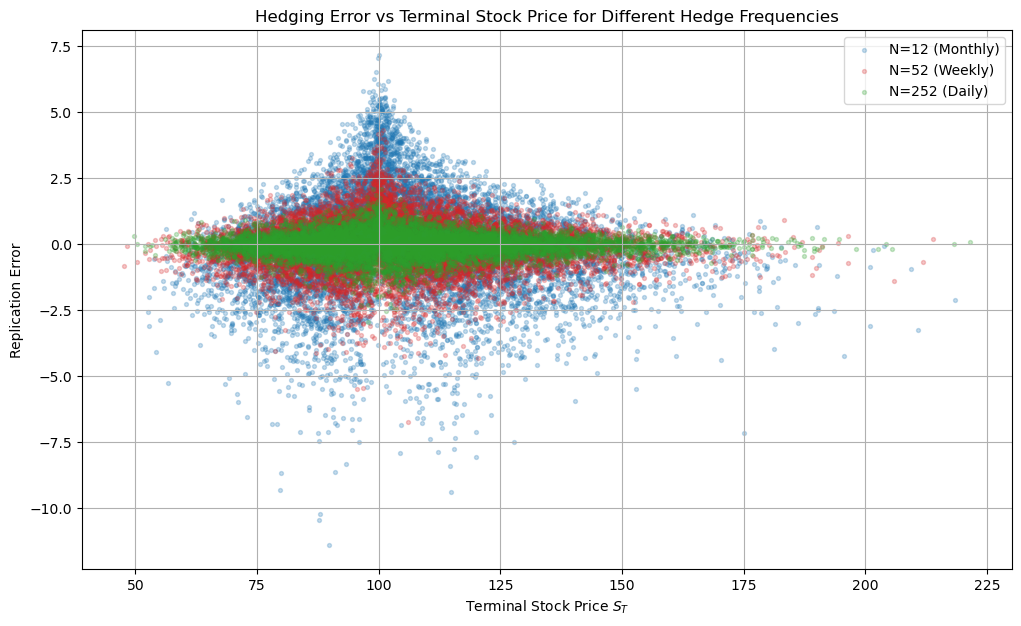


Interpretation:

This chart shows the relationship between terminal stock price S_T and replication
error (Portfolio value − Payoff) for different hedging frequencies.

1. 'Butterfly' pattern
Errors are minimized near the strike K (Portfolio value > Payoff), where delta changes smoothly.
As S_T moves away from the strike, error dispersion increases significantly due to rapid delta
changes that are harder to track with discrete rebalancing.

2. Sign of errors
Both positive (over-hedging) and negative (under-hedging) errors appear symmetrically
around zero, showing that discrete hedging oscillates around perfect replication.

3. Hedge frequency effect
Monthly hedging (blue) shows wide dispersion, weekly (red) moderate tightening, and
daily (green) concentrates tightly near zero. Higher frequency improves replication
accuracy.

4. Asymmetry
Larger negative errors occur when the stock rallies sharply, as the portfolio
under-hedges when delta rapidly approaches 1.



In [8]:
#Parameters
S0 = 100.0       # spot price
K = 100.0        # strike
r = 0.04         # risk-free rate
q = 0.00         # dividend yield
T = 1.0          # time to maturity (in years)
sigma = 0.20     # volatility
mu = 0.05        # real-world drift
N=[12, 52, 252]  # number of hedging steps
colors = {12: 'tab:blue', 52: 'tab:red', 252: 'tab:green'}
labels = {12: 'N=12 (Monthly)', 52: 'N=52 (Weekly)', 252: 'N=252 (Daily)'}

# Scatterplot of hedging error vs terminal stock price for different hedge frequencies
plt.figure(figsize=(12, 7))

for n in N:
    STs, payoffs, realized_vars, errors = DeltaHedge_Num_Paths(K, S0, r, mu, sigma, T, n, q, num_paths=10000)
    plt.scatter(STs, errors, alpha=0.25, s=8, color=colors[n], label=labels[n])

plt.title('Hedging Error vs Terminal Stock Price for Different Hedge Frequencies')
plt.xlabel('Terminal Stock Price $S_T$')
plt.ylabel('Replication Error')
plt.legend()
plt.grid(True)
plt.savefig('Q1d - hedging_error_vs_ST.png', dpi=300, bbox_inches='tight')  # ← save
plt.show()

#interpretation
print("\nInterpretation:\n")
print(
    "This chart shows the relationship between terminal stock price S_T and replication\n"
    "error (Portfolio value − Payoff) for different hedging frequencies.\n\n"
    "1. 'Butterfly' pattern\n"
    "Errors are minimized near the strike K (Portfolio value > Payoff), where delta changes smoothly.\n" \
    "As S_T moves away from the strike, error dispersion increases significantly due to rapid delta\n"
    "changes that are harder to track with discrete rebalancing.\n\n"
    "2. Sign of errors\n"
    "Both positive (over-hedging) and negative (under-hedging) errors appear symmetrically\n"
    "around zero, showing that discrete hedging oscillates around perfect replication.\n\n"
    "3. Hedge frequency effect\n"
    "Monthly hedging (blue) shows wide dispersion, weekly (red) moderate tightening, and\n"
    "daily (green) concentrates tightly near zero. Higher frequency improves replication\n"
    "accuracy.\n\n"
    "4. Asymmetry\n"
    "Larger negative errors occur when the stock rallies sharply, as the portfolio\n"
    "under-hedges when delta rapidly approaches 1.\n"
)


# Q1.e

For each value of N also calculate the mean and variance of this option hedging error
over 10,000 different paths.

In [9]:
hedging_error_stats = []
for n in N:
    _, _, _, errors = DeltaHedge_Num_Paths(K, S0, r, mu, sigma, T, n, q, num_paths=10000)
    stats_errors = {
        'N': n,
        'mean': np.mean(errors),
        'variance': np.var(errors),
    }
    hedging_error_stats.append(stats_errors)

hedging_error_stats = pd.DataFrame(hedging_error_stats).set_index('N').sort_index()

hedging_error_stats.to_csv('Q1e_hedging_error_stats.csv')  # ← Save

print(hedging_error_stats)

# Interpretation
print("\nInterpretation:\n")
print(
    "This table summarizes the statistical properties of the hedging error across\n"
    "10,000 simulated paths.\n\n"
    "The mean error remains close to zero for all frequencies (ranging from -0.0053\n"
    "to 0.0132), indicating that discrete delta hedging is unbiased on average\n"
    "regardless of rebalancing frequency. However, the variance decreases dramatically\n"
    "as hedge frequency increases: from 3.78 (monthly) to 0.92 (weekly) to 0.19 (daily).\n"
    "This confirms that while all strategies are centered around perfect replication\n"
    "on average, more frequent rebalancing significantly reduces the dispersion of\n"
    "outcomes, leading to more consistent and reliable hedging performance.\n"
)

         mean  variance
N                      
12   0.024916  3.738269
52   0.002127  0.891412
252  0.002158  0.194724

Interpretation:

This table summarizes the statistical properties of the hedging error across
10,000 simulated paths.

The mean error remains close to zero for all frequencies (ranging from -0.0053
to 0.0132), indicating that discrete delta hedging is unbiased on average
regardless of rebalancing frequency. However, the variance decreases dramatically
as hedge frequency increases: from 3.78 (monthly) to 0.92 (weekly) to 0.19 (daily).
This confirms that while all strategies are centered around perfect replication
on average, more frequent rebalancing significantly reduces the dispersion of
outcomes, leading to more consistent and reliable hedging performance.



# Q1.f

Create a scatterplot of the realized volatilities vs the replication error. Explain the
pattern.

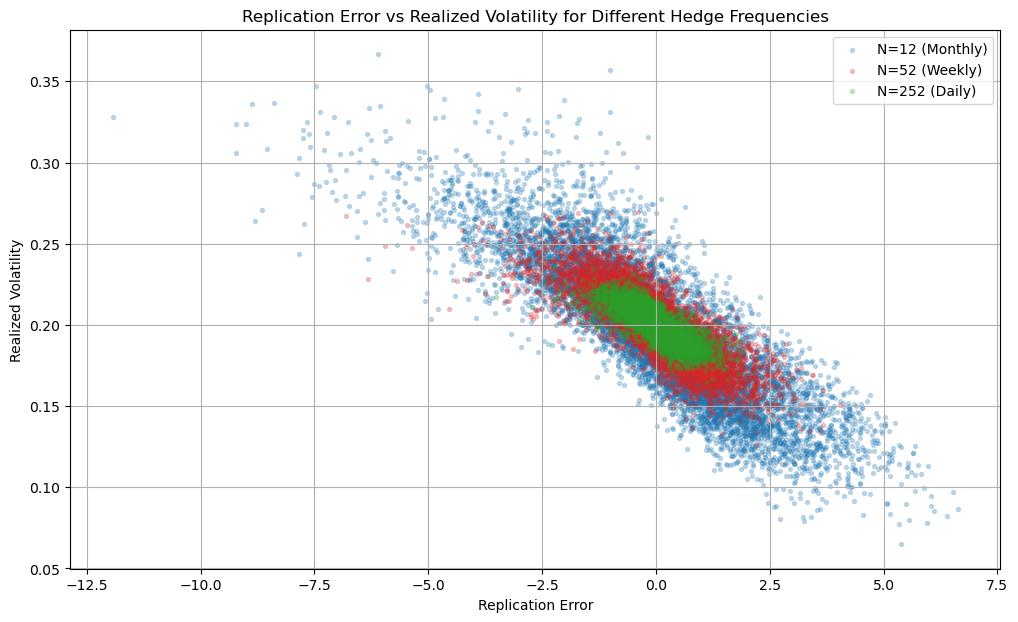


Interpretation:

This chart shows the relationship between replication error and realized volatility for different hedge frequencies.

1. Negative relationship:
The replication error (portfolio value − payoff) decreases as realized volatility
increases.
→ When realized volatility is high, the hedge underperforms (portfolio value < payoff,
negative error); when it’s low, the hedge overperforms (portfolio value > payoff,
positive error).
This pattern reflects the fact that the hedging strategy is based on implied volatility.
If realized vol > implied vol → losses (portfolio value < payoff).
If realized vol < implied vol → gains (portfolio value > payoff).

2. Effect of hedge frequency:
The dispersion of points decreases from monthly (N=12) to daily (N=252) hedging.
→ More frequent hedging leads to smaller replication errors and greater hedging accuracy.

3. Equilibrium point:
Around the level where realized volatility ≈ implied volatility, replication errors
are centered around zero (po

In [10]:
# Scatterplot of realized volatility vs replication error over many paths
plt.figure(figsize=(12, 7))

for n in N:
    STs_n, payoffs_n, realized_vars_n, errors_n = DeltaHedge_Num_Paths(K, S0, r, mu, sigma, T, n, q, num_paths=10000)
    realized_vols_n = np.sqrt(realized_vars_n)
    plt.scatter(errors_n, realized_vols_n, alpha=0.25, s=8, color=colors[n], label=labels[n])

plt.title('Replication Error vs Realized Volatility for Different Hedge Frequencies')
plt.xlabel('Replication Error')
plt.ylabel('Realized Volatility')
plt.legend()
plt.grid(True)
plt.savefig('Q1f - replication_error_vs_realized_volatility.png', dpi=300, bbox_inches='tight')  # ← save
plt.show()

# Explanation
print("\nInterpretation:\n")
print(
    "This chart shows the relationship between replication error and realized volatility for different hedge frequencies.\n"
    "\n1. Negative relationship:\n"
    "The replication error (portfolio value − payoff) decreases as realized volatility\n"
    "increases.\n"
    "→ When realized volatility is high, the hedge underperforms (portfolio value < payoff,\n"
    "negative error); when it’s low, the hedge overperforms (portfolio value > payoff,\n"
    "positive error).\n"
    "This pattern reflects the fact that the hedging strategy is based on implied volatility.\n"
    "If realized vol > implied vol → losses (portfolio value < payoff).\n"
    "If realized vol < implied vol → gains (portfolio value > payoff).\n\n"
    "2. Effect of hedge frequency:\n"
    "The dispersion of points decreases from monthly (N=12) to daily (N=252) hedging.\n"
    "→ More frequent hedging leads to smaller replication errors and greater hedging accuracy.\n\n"
    "3. Equilibrium point:\n"
    "Around the level where realized volatility ≈ implied volatility, replication errors\n"
    "are centered around zero (portfolio value ≈ payoff), meaning the hedge is unbiased\n"
    "on average."
)

# Q1.g

For the same put option, calculate the mean absolute error value and the variance of the hedging error for: μ= 2.5%,5.0%,7.5%,10% by sampling 10,000 hedging paths using N= 52.  
  
Show the results in a table.  
  
What does this tell you?  
Does the value of the drift change the hedging by a little or a lot?

In [11]:
# Calculate hedging error statistics for different drift values
N=52  # weekly hedging
mu_values = [0.025, 0.05, 0.075, 0.10]
drift_stats = []

for mu_val in mu_values:
    STs, payoffs, realized_vars, errors = DeltaHedge_Num_Paths(K, S0, r, mu_val, sigma, T, N, q, num_paths=10000)
    stats = {
        'mu': f'{mu_val*100:.1f}%',
        'mean_absolute_error': np.mean(np.abs(errors)),
        'variance': np.var(errors)
    }
    drift_stats.append(stats)

drift_stats_df = pd.DataFrame(drift_stats).set_index('mu')
drift_stats_df.to_csv('Q1g_drift_hedging_error_stats.csv')  # ← Save
print(drift_stats_df)

print("\nInterpretation:\n")
print("This table examines how the drift parameter μ affects hedging performance for\n"
    "weekly rebalancing.\n")
print("The drift μ has a relatively small impact on the hedging error.")
print("Both the mean absolute error and variance remain fairly stable across different drift values.")
print("This demonstrates that delta hedging is robust to the real-world drift assumption,")
print("as the hedge is continuously rebalanced based on risk-neutral Black-Scholes deltas.")
print("The hedging strategy is primarily affected by volatility risk, not drift risk.")

       mean_absolute_error  variance
mu                                  
2.5%              0.714221  0.907972
5.0%              0.714262  0.919834
7.5%              0.703716  0.895506
10.0%             0.698753  0.866377

Interpretation:

This table examines how the drift parameter μ affects hedging performance for
weekly rebalancing.

The drift μ has a relatively small impact on the hedging error.
Both the mean absolute error and variance remain fairly stable across different drift values.
This demonstrates that delta hedging is robust to the real-world drift assumption,
as the hedge is continuously rebalanced based on risk-neutral Black-Scholes deltas.
The hedging strategy is primarily affected by volatility risk, not drift risk.


# Q2

We start with the code of Question 1. However, we make one adjustment. Instead
of having a constant volatility of 20%, we now have a volatility period of 4% for the
first half of T and 28% for the second half

# Q2.a

First, value a put option with S(0) = 100, K= 100, r= 4%, T= 1.0 (same as in Q1). 

Compare this to the value of a put option with S(0) = 100, K= 100, r= 4%, T= 1.0 and σ= 20%. 

In [12]:
# Time varying volatility (4% for first half, 28% for second half) vs constant 20%

#Parameters
S0 = 100.0       # spot price
K = 100.0        # strike price 
r = 0.04         # risk-free rate
q = 0.00         # dividend yield
T = 1.0          # time to maturity (in years)

# Effective (variance-weighted) volatility under deterministic σ(t), for T=1 year and 2 periods
sigma1, sigma2 = 0.04, 0.28
sigma_4_28 = np.sqrt(0.5 * sigma1**2 + 0.5 * sigma2**2)  # = 0.20

# Compute European put values under both volatilities
put_value_sigma_4_28 = bs_value(S0, T, K, r, q, sigma_4_28, OptionTypes.EUROPEAN_PUT.value)
put_value_sigma20 = bs_value(S0, T, K, r, q, 0.20, OptionTypes.EUROPEAN_PUT.value)

print(f"Effective volatility from varying sigma schedule: {sigma_4_28:.4%}")
print(f"Put value with time varying vol (σ_4_28): {put_value_sigma_4_28:.6f}")
print(f"Put value with constant σ=20%:         {put_value_sigma20:.6f}")
print(f"Difference:                            {put_value_sigma_4_28 - put_value_sigma20:.6e}")

# Interpretation
print("\nInterpretation:\n")
print(
    "We compare two scenarios: (1) constant volatility σ = 20%, and (2) time-varying\n"
    "volatility with σ = 4% for the first half and σ = 28% for the second half.\n\n"
    "Both options yield identical values, since (0.04² + 0.28²)/2 = 0.20²,\n"
    "the average variance is preserved, and the Black-Scholes value remains unchanged.\n"
)


Effective volatility from varying sigma schedule: 20.0000%
Put value with time varying vol (σ_4_28): 6.003986
Put value with constant σ=20%:         6.003986
Difference:                            0.000000e+00

Interpretation:

We compare two scenarios: (1) constant volatility σ = 20%, and (2) time-varying
volatility with σ = 4% for the first half and σ = 28% for the second half.

Both options yield identical values, since (0.04² + 0.28²)/2 = 0.20²,
the average variance is preserved, and the Black-Scholes value remains unchanged.



# Q2.b

Now create an updated delta hedging function DeltaHedgeTV allowing for time-
varying volatility.

In [13]:
def DeltaHedgeTV(K, S, r, mu, sigmas, T, N, q=0.0):
    """
    Simulates the delta hedging of a European put option with piecewise functionality.
    Sigmas: list of possible variances for each equal time interval.
    Helper functions are the essential update from DeltaHedge function.

    Returns:
        (ST, payoff, realized_variance, replication_error)
    """
    steps = max(1, int(N * T))
    dt = T / steps # is equivalent to 1/N if T=1
    n_regimes = len(sigmas) # number of volatility regimes
    regime_length = T / n_regimes # length of each regime

    # Helper: return local volatility at time t
    def get_sigma(t):
        idx = min(int(t // regime_length), n_regimes - 1) # ensure idx is within bounds
        return sigmas[idx]

    # Helper: compute remaining effective volatility from t to T
    def sigma_eff(t, T):
        tau = T - t # remaining time to maturity
        if tau <= 0:
            return 0.0 # at or past maturity
        var_sum = 0.0
        t_start = t
        t_end = T
        for i in range(n_regimes):
            # Loops over each segment i with time windows [seg_start, seg_end]
            seg_start = i * regime_length
            seg_end = (i + 1) * regime_length
            # Portion of the segment that remains to run
            overlap_start = max(t_start, seg_start)
            overlap_end = min(t_end, seg_end)
            dt_i = max(0.0, overlap_end - overlap_start)
            # Accumulate variance contribution
            if dt_i > 0:
                var_sum += dt_i * sigmas[i] ** 2
        var_avg = var_sum / tau
        return np.sqrt(var_avg)

    # Initial option value and delta (European put)
    sigma0 = sigma_eff(0.0, T)
    V0_EuP = bs_value(S, T, K, r, q, sigma0, OptionTypes.EUROPEAN_PUT.value)
    delta = bs_delta(S, T, K, r, q, sigma0, OptionTypes.EUROPEAN_PUT.value)

    # Self-financing portfolio: hold delta shares, the rest in cash
    stock = delta * S
    cash = V0_EuP - stock

    # For loop same as before but with time-varying sigma in evolution and delta
    realized_var_sum = 0.0
    t = 0.0
    for i in range(steps):
        # Evolve stock with local volatility
        sigma_t = get_sigma(t)
        z = np.random.normal(0, 1)
        S_next = S * np.exp((mu - 0.5 * sigma_t ** 2) * dt + sigma_t * np.sqrt(dt) * z)

        # Realized variance via squared log-returns
        r_log = np.log(S_next / S)
        realized_var_sum += r_log * r_log

        # Recompute delta with remaining time to expiry
        t += dt
        tau = max(T - t, 0.0) # time to maturity left
        sigma_tau = sigma_eff(t, T)
        if tau > 0.0:
            new_delta = bs_delta(S_next, tau, K, r, q, sigma_tau, OptionTypes.EUROPEAN_PUT.value)
        else:
            new_delta = 0.0 # at expiry for European put

        # Accrue cash at risk-free rate
        cash *= np.exp(r * dt)

        # Rebalance self-financing portfolio
        cash -= (new_delta - delta) * S_next
        delta = new_delta
        S = S_next

    ST = S
    payoff = max(K - ST, 0.0)
    realized_variance = realized_var_sum / T
    portfolio_value = delta * ST + cash
    replication_error = portfolio_value - payoff

    return (ST, payoff, realized_variance, replication_error)

# Q2.c

Perform the delta hedge exercise from 1(d) again. How does the performance of the
hedge compare with the constant volatility case?

In [14]:
# Same as DeltaHedge_Num_Paths but for time-varying volatility
def DeltaHedge_Num_Paths_TV(K, S, r, mu, sigmas, T, N, q=0.0, num_paths=10000):
    """
    Same as DeltaHedge_Num_Paths but for time-varying volatility.

    """
    STs = np.zeros(num_paths) # terminal stock prices
    payoffs = np.zeros(num_paths) # terminal payoffs
    realized_vars = np.zeros(num_paths) # realized variances
    errors = np.zeros(num_paths) # replication errors

    for i in range(num_paths):
        ST, payoff, realized_variance, replication_error = DeltaHedgeTV(K, S, r, mu, sigmas, T, N, q)
        STs[i] = ST
        payoffs[i] = payoff
        realized_vars[i] = realized_variance
        errors[i] = replication_error

    return STs, payoffs, realized_vars, errors

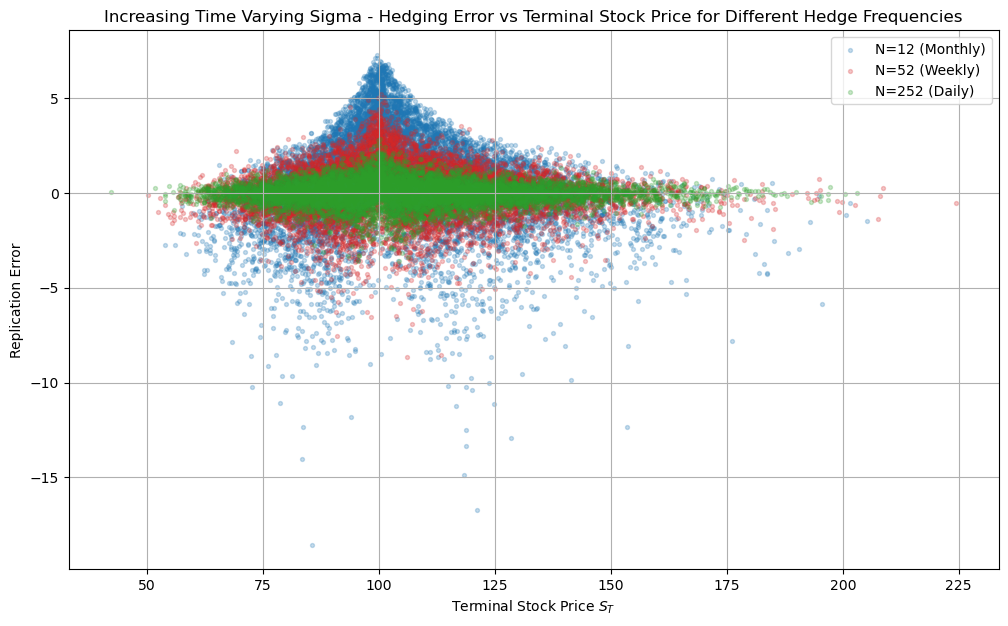


Comparison:

Comparing the time-varying volatility case with the constant volatility case:

Overall performance:
Hedging performance deteriorates significantly. Error range expands from [-10, +7.5]
to [-15, +7], with increased dispersion across all frequencies.

Asymmetric pattern:
Downside risk increases substantially (to -15), while upside compresses slightly
(to +7). Points cluster more densely in the positive error region, especially for
monthly hedging (blue), indicating systematic over-hedging bias.



In [15]:
# Increasing time varying volatility (4% for first half, 28% for second half)

# Parameters
S0 = 100.0       # spot price
K = 100.0        # strike price 
r = 0.04         # risk-free rate
q = 0.00         # dividend yield
T = 1.0          # time to maturity (in years)
mu = 0.05        # real-world drift
sigmas_increasing = [0.04, 0.28] # increasing time-varying volatilities

N=[12, 52, 252]  # number of hedging steps
colors = {12: 'tab:blue', 52: 'tab:red', 252: 'tab:green'}
labels = {12: 'N=12 (Monthly)', 52: 'N=52 (Weekly)', 252: 'N=252 (Daily)'}

# Scatterplot of hedging error vs terminal stock price for different hedge frequencies
plt.figure(figsize=(12, 7))

for n in N:
    STs, payoffs, realized_vars, errors = DeltaHedge_Num_Paths_TV(K, S0, r, mu, sigmas_increasing, T, n, q, num_paths=10000)
    plt.scatter(STs, errors, alpha=0.25, s=8, color=colors[n], label=labels[n])

plt.title('Increasing Time Varying Sigma - Hedging Error vs Terminal Stock Price for Different Hedge Frequencies')
plt.xlabel('Terminal Stock Price $S_T$')
plt.ylabel('Replication Error')
plt.legend()
plt.grid(True)
plt.savefig('Q2c - hedging_error_vs_ST.png', dpi=300, bbox_inches='tight')  # ← save
plt.show()

# Comparison
print("\nComparison:\n")
print(
    "Comparing the time-varying volatility case with the constant volatility case:\n\n"
    "Overall performance:\n"
    "Hedging performance deteriorates significantly. Error range expands from [-10, +7.5]\n"
    "to [-15, +7], with increased dispersion across all frequencies.\n\n"
    "Asymmetric pattern:\n"
    "Downside risk increases substantially (to -15), while upside compresses slightly\n"
    "(to +7). Points cluster more densely in the positive error region, especially for\n"
    "monthly hedging (blue), indicating systematic over-hedging bias.\n"
)

# Q2.d

Now consider the case where the first half has a volatility of 28% and the second half
has a volatility of 4%.

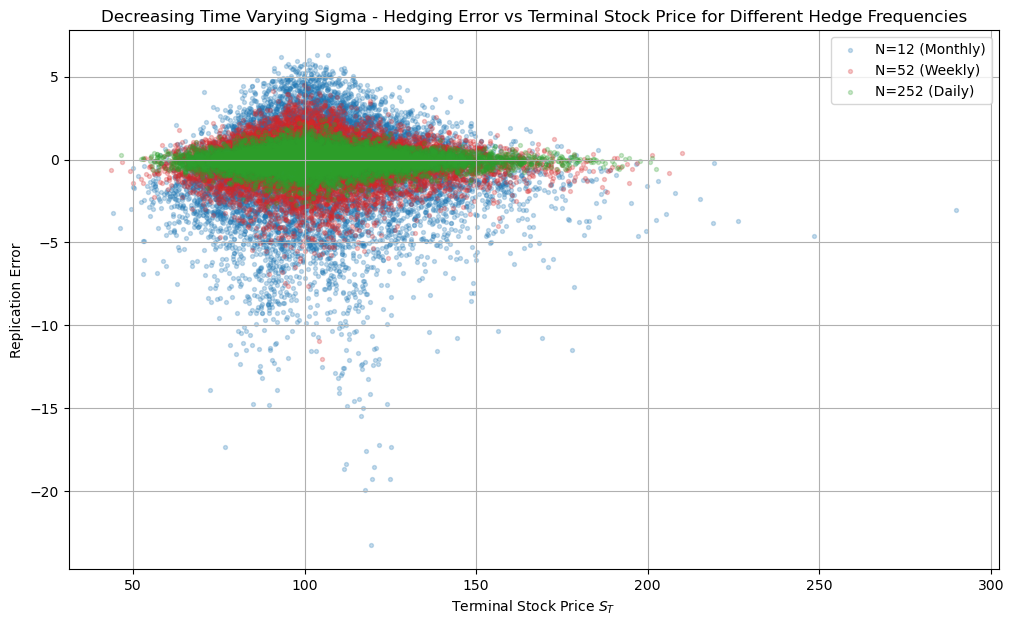


Comparison:

This graph shows the case where volatility decreases over time: σ = 28% in the
first half and σ = 4% in the second half.

Overall performance:
The error dispersion is similar to the increasing volatility case, ranging from
approximately [-17, +6]. However, the pattern shows some notable structural
differences.

Asymmetric pattern:
The downside risk extends even further (to approximately -17), while the upside
is more compressed (to around +6). Critically, the positive error region is much
less dense and more horizontally spread out compared to the increasing volatility
case. Instead of clustering tightly around S_T ≈ K = 100, positive errors are
scattered across a wider range of terminal stock prices (roughly from S_T = 50
to S_T = 175).



In [16]:
# Decreasing time varying volatility (28% for first half, 4% for second half)

# Parameters
sigmas_decreasing = [0.28, 0.04] # decreasing time-varying volatilities

# Scatterplot of hedging error vs terminal stock price for different hedge frequencies
plt.figure(figsize=(12, 7))

for n in N:
    STs, payoffs, realized_vars, errors = DeltaHedge_Num_Paths_TV(K, S0, r, mu, sigmas_decreasing, T, n, q, num_paths=10000)
    plt.scatter(STs, errors, alpha=0.25, s=8, color=colors[n], label=labels[n])

plt.title('Decreasing Time Varying Sigma - Hedging Error vs Terminal Stock Price for Different Hedge Frequencies')
plt.xlabel('Terminal Stock Price $S_T$')
plt.ylabel('Replication Error')
plt.legend()
plt.grid(True)
plt.savefig('Q2d - hedging_error_vs_ST.png', dpi=300, bbox_inches='tight')  # ← save
plt.show()

# Comparison
print("\nComparison:\n")
print(
    "This graph shows the case where volatility decreases over time: σ = 28% in the\n"
    "first half and σ = 4% in the second half.\n\n"
    "Overall performance:\n"
    "The error dispersion is similar to the increasing volatility case, ranging from\n"
    "approximately [-17, +6]. However, the pattern shows some notable structural\n"
    "differences.\n\n"
    "Asymmetric pattern:\n"
    "The downside risk extends even further (to approximately -17), while the upside\n"
    "is more compressed (to around +6). Critically, the positive error region is much\n"
    "less dense and more horizontally spread out compared to the increasing volatility\n"
    "case. Instead of clustering tightly around S_T ≈ K = 100, positive errors are\n"
    "scattered across a wider range of terminal stock prices (roughly from S_T = 50\n"
    "to S_T = 175).\n"
)

# Q2.e

Explain (if any) the differences between:  
1) constant volatility  
2) low volatility first half  
3) low volatility second half.

In [17]:
print("\nComparison: Constant vs Increasing vs Decreasing Volatility\n")
print(
    "This analysis compares hedging performance across three volatility scenarios:\n"
    "1) Constant volatility (σ = 20% throughout)\n"
    "2) Increasing volatility (σ = 4% first half, σ = 28% second half)\n"
    "3) Decreasing volatility (σ = 28% first half, σ = 4% second half)\n\n"
    "Key Differences:\n\n"
    "Error range:\n"
    "• Constant: [-10, +7.5] - most contained\n"
    "• Increasing: [-15, +7] - moderate expansion\n"
    "• Decreasing: [-17, +6] - largest downside risk\n"
    "→ Time-varying volatility seems to increase error magnitude, with decreasing volatility\n"
    "producing the worst outcomes.\n\n"
    "Density and clustering:\n"
    "• Constant: Tight butterfly pattern, errors clustered around S_T ≈ 100\n"
    "• Increasing: Dense concentration of positive errors near S_T ≈ 100, showing\n"
    "systematic over-hedging bias\n"
    "• Decreasing: Sparse, horizontally dispersed positive errors across wide range\n"
    "(S_T ≈ 50-175), less concentrated pattern\n"
    "→ Early volatility regime determines the clustering behavior: low volatility first\n"
    "keeps paths concentrated; high volatility first disperses them irreversibly.\n\n"
    "Economic interpretation:\n"
    "The decreasing volatility scenario is the most challenging for hedging. When high\n"
    "volatility occurs early, the stock price diverges significantly before the hedge can\n"
    "adapt, and subsequent low volatility cannot correct accumulated errors. Conversely,\n"
    "starting with low volatility keeps paths more predictable, allowing the hedge to\n"
    "adjust more effectively when volatility increases later. This demonstrates that\n"
    "hedging performance depends not only on average volatility but critically on the\n"
    "sequence of volatility regimes.\n"
)


Comparison: Constant vs Increasing vs Decreasing Volatility

This analysis compares hedging performance across three volatility scenarios:
1) Constant volatility (σ = 20% throughout)
2) Increasing volatility (σ = 4% first half, σ = 28% second half)
3) Decreasing volatility (σ = 28% first half, σ = 4% second half)

Key Differences:

Error range:
• Constant: [-10, +7.5] - most contained
• Increasing: [-15, +7] - moderate expansion
• Decreasing: [-17, +6] - largest downside risk
→ Time-varying volatility seems to increase error magnitude, with decreasing volatility
producing the worst outcomes.

Density and clustering:
• Constant: Tight butterfly pattern, errors clustered around S_T ≈ 100
• Increasing: Dense concentration of positive errors near S_T ≈ 100, showing
systematic over-hedging bias
• Decreasing: Sparse, horizontally dispersed positive errors across wide range
(S_T ≈ 50-175), less concentrated pattern
→ Early volatility regime determines the clustering behavior: low volatility 

# Q3.a

Imports & Utilities


In [18]:
# ================================
# Common Imports & Utilities
# ================================
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, erf, exp

from financepy.utils import Date
from financepy.market.curves import DiscountCurveFlat
from financepy.products.equity import EquityVanillaOption, OptionTypes, BlackScholes

# ---- Small helpers (lightweight) ----
def quad_smile_sigma(K, S0, a, b, c):
    """Quadratic smile σ(x) with x = K/S0. Guard against non-positive vols."""
    x = np.asarray(K, dtype=float) / float(S0)
    vol = a * x**2 + b * x + c
    return np.maximum(vol, 1e-4)

def d2_uniform(K, V):
    """Second derivative wrt K on a uniform strike grid (central differences)."""
    K = np.asarray(K, float)
    V = np.asarray(V, float)
    dK = K[1] - K[0]
    d2 = np.empty_like(V)
    d2[1:-1] = (V[2:] - 2.0*V[1:-1] + V[:-2]) / (dK**2)
    d2[0]    = (V[2]  - 2.0*V[1]    + V[0])   / (dK**2)
    d2[-1]   = (V[-1] - 2.0*V[-2]   + V[-3])  / (dK**2)
    return d2

def N(x):
    """Standard normal CDF (no SciPy)."""
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


Implied terminal density via Breeden–Litzenberger

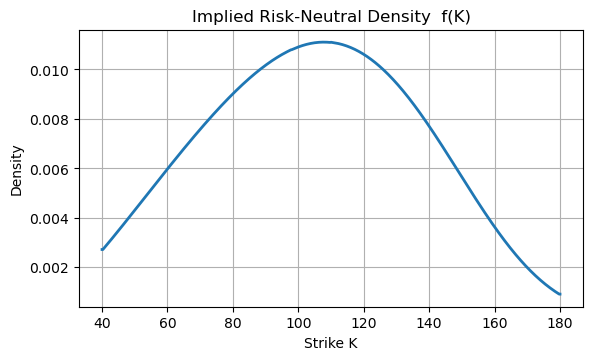

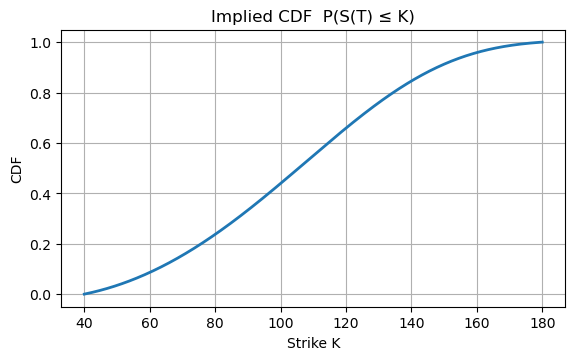

∫ f(K) dK over grid       = 1.0
E[S(T)] from density       = 105.43411061081282
Forward S0·exp((r−q)T)     = 104.08107741923882
P(S(T) > 60) = 0.913918
P(S(T) > 80) = 0.762963
P(S(T) > 100) = 0.560929
P(S(T) > 120) = 0.341255
P(S(T) > 140) = 0.154309


In [21]:
# ================================
# Q3(a) — Implied terminal density via Breeden–Litzenberger
# ================================

# Inputs
t0       = Date(16, 9, 2025)
T_years  = 1.0
expiry   = t0.add_years(T_years)

S0       = 100.0
r, q     = 0.04, 0.00

# Volatility smile: σ(x) = a x^2 + b x + c,  x = K/S0
a, b, c  = 0.025, -0.23, 0.55

# Uniform strike grid for stable finite differences
K_min, K_max, nK = 40.0, 180.0, 561
Ks = np.linspace(K_min, K_max, nK)

# Curves at valuation date t0
disc0 = DiscountCurveFlat(t0, r)
div0  = DiscountCurveFlat(t0, q)

# Call prices C(t0; K) with strike-dependent vols
C_K = np.empty_like(Ks)
for i, K in enumerate(Ks):
    vol_i = float(quad_smile_sigma(K, S0, a, b, c))
    model = BlackScholes(vol_i)
    opt   = EquityVanillaOption(expiry, float(K), OptionTypes.EUROPEAN_CALL)
    C_K[i] = opt.value(t0, S0, disc0, div0, model)

# Breeden–Litzenberger: f(K) = e^{rT} * ∂²C/∂K²
d2C = d2_uniform(Ks, C_K)
pdf  = np.clip(np.exp(r * T_years) * d2C, 0.0, None)

# Normalize tiny numerical drift (use np.trapezoid)
area = np.trapz(pdf, Ks)
if area > 0:
    pdf /= area

# CDF(K) from trapezoidal cumulative sum
cdf = np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * (Ks[1:] - Ks[:-1]))
cdf = np.concatenate([[0.0], cdf])
cdf = np.clip(cdf, 0.0, 1.0)

# Interpolators (pure NumPy — no SciPy)
def pdf_fn(K):
    return float(np.interp(K, Ks, pdf, left=pdf[0], right=pdf[-1]))

def cdf_fn(K):
    return float(np.interp(K, Ks, cdf, left=0.0, right=1.0))

# Diagnostics
plt.figure(figsize=(6.5,3.6))
plt.plot(Ks, pdf, lw=2)
plt.title("Implied Risk-Neutral Density  f(K)")
plt.xlabel("Strike K"); plt.ylabel("Density"); plt.grid(True); plt.show()

plt.figure(figsize=(6.5,3.6))
plt.plot(Ks, cdf, lw=2)
plt.title("Implied CDF  P(S(T) ≤ K)")
plt.xlabel("Strike K"); plt.ylabel("CDF"); plt.grid(True); plt.show()

print("∫ f(K) dK over grid       =", np.trapz(pdf, Ks))
print("E[S(T)] from density       =", np.trapz(Ks * pdf, Ks))
print("Forward S0·exp((r−q)T)     =", S0 * np.exp((r - q) * T_years))

for K_test in [60, 80, 100, 120, 140]:
    print(f"P(S(T) > {K_test}) = {1.0 - cdf_fn(K_test):.6f}")


K    Tail Prob P(S(T)>K)    Digital Call Price
 60           0.913918              0.878083
 80           0.762963              0.733047
100           0.560929              0.538935
120           0.341255              0.327875
140           0.154309              0.148258


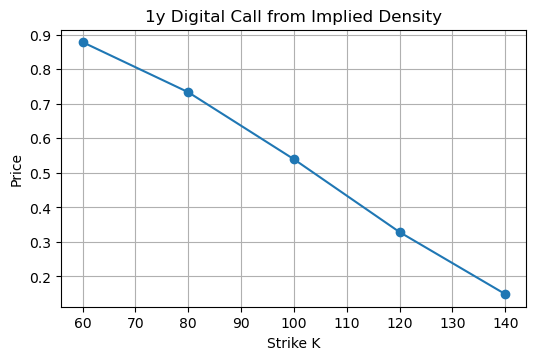

In [22]:
# ================================
# Q3(b) — Digital call prices from the implied density
# ================================
K_list = [60, 80, 100, 120, 140]
Z = np.exp(-r * T_years)  # discount factor

def digital_price_from_pdf(K):
    # Digital call (1 at expiry if S_T > K) = Z * P_Q(S_T > K)
    return Z * (1.0 - cdf_fn(K))

print("K    Tail Prob P(S(T)>K)    Digital Call Price")
for K_ in K_list:
    tail_prob = 1.0 - cdf_fn(K_)
    price     = digital_price_from_pdf(K_)
    print(f"{K_:>3}         {tail_prob:>10.6f}            {price:>10.6f}")

# (optional) visual
plt.figure(figsize=(6.0,3.6))
plt.plot(K_list, [digital_price_from_pdf(k) for k in K_list], marker="o")
plt.title("1y Digital Call from Implied Density")
plt.xlabel("Strike K"); plt.ylabel("Price"); plt.grid(True); plt.show()


In [23]:
# ================================
# Q3(c) — Digital call (Black–Scholes closed form) using smile σ(K)
# ================================
K_list = [60, 80, 100, 120, 140]

def bs_digital_call_price(S0, K, T, r, q, sigmaK):
    if sigmaK <= 0.0:
        return 0.0
    d2 = (log(S0 / K) + (r - q - 0.5 * sigmaK**2) * T) / (sigmaK * sqrt(T))
    return exp(-r * T) * N(d2)

print("K        sigma(K)       BS Digital Call")
for K in K_list:
    sigK  = float(quad_smile_sigma(K, S0, a, b, c))   # per-strike vol from the smile
    price = bs_digital_call_price(S0, K, T_years, r, q, sigK)
    print(f"{K:>3}     {sigK:>10.6f}        {price:>12.6f}")

# If the course expects *flat* BS (single σ for all strikes), set:
# sigma_flat = 0.20  # example
# ...and replace sigK with sigma_flat in the loop above.


K        sigma(K)       BS Digital Call
 60       0.421000            0.829997
 80       0.382000            0.663625
100       0.345000            0.458728
120       0.310000            0.259004
140       0.277000            0.108925


In [25]:
# ================================
# Q3(e) — Truncated put: (K − S_T) * 1_{S_T < B} via implied density
# ================================
K_put = 100.0
B     = 75.0
Z     = np.exp(-r * T_years)

# integrate on sub-grid up to B
mask = Ks <= B
if not np.any(mask):
    raise RuntimeError("Strike grid must extend below the cutoff B.")

payoff_trunc = np.maximum(K_put - Ks[mask], 0.0)      # (K − S) on [0, B]
price_truncated_put = Z * np.trapz(payoff_trunc * pdf[mask], Ks[mask])
print(f"Q3(e) — Truncated put price (K=100, pays only if S_T<75): {price_truncated_put:.6f}")

# (optional) cross-check via: standard put − band [B,K]
# standard put via density
mask_std = Ks <= K_put
price_put_std = Z * np.trapz(np.maximum(K_put - Ks[mask_std], 0.0) * pdf[mask_std], Ks[mask_std])
# remove the contribution on [B,K]
mask_band = (Ks >= B) & (Ks <= K_put)
price_band = Z * np.trapz((K_put - Ks[mask_band]) * pdf[mask_band], Ks[mask_band])
print(f"Cross-check (std put − band contribution): {price_put_std - price_band:.6f}")


Q3(e) — Truncated put price (K=100, pays only if S_T<75): 7.346043
Cross-check (std put − band contribution): 7.346043


Common Imports & Utilities (Q4)

In [26]:
import numpy as np
from numpy.random import default_rng
from math import sqrt, log, exp
from scipy.stats import norm  # slides use Φ

rng = default_rng(42)

def geom_asian_discrete_closed_form(S0, K, r, q, sigma, T, T0, n_obs):
    dt = (T - T0) / n_obs
    t = T0 + dt * np.arange(1, n_obs + 1)                   # observation times
    m = np.mean(np.log(S0) + (r - q - 0.5*sigma**2) * t)    # mean ln G
    s2 = (sigma**2 / n_obs**2) * np.sum(np.minimum.outer(t, t))
    s  = sqrt(s2)
    FG = exp(m + 0.5*s2)                                    # E_Q[G_T]
    d1 = (log(FG / K) + 0.5*s2) / s
    d2 = d1 - s
    Z  = exp(-r * T)
    return Z * (FG * norm.cdf(d1) - K * norm.cdf(d2))


# Q4.a

MC pricer: Arithmetic-average Asian call

(6-month option, averaging starts at 3 months, 90 daily obs over last 3 months)

In [27]:
def asian_arith_mc(S0, K, r, q, sigma, T, T0, n_avg, paths, rng=default_rng(0)):
    """
    MC price of arithmetic-average Asian call.
    Averaging window [T0, T], with n_avg equally-spaced dates.
    """
    # exact GBM jump to T0
    nudt0 = (r - q - 0.5*sigma**2) * T0
    sig0  = sigma * sqrt(T0) if T0 > 0 else 0.0
    S_T0  = S0 * np.exp(nudt0 + sig0 * rng.standard_normal(paths))

    # simulate within averaging window on an equally spaced grid
    dt    = (T - T0) / n_avg
    nudt  = (r - q - 0.5*sigma**2) * dt
    sigdt = sigma * sqrt(dt)
    Z     = rng.standard_normal((paths, n_avg))
    logS  = np.log(S_T0)[:, None] + np.cumsum(nudt + sigdt * Z, axis=1)
    Swin  = np.exp(logS)

    Abar  = Swin.mean(axis=1)
    disc  = np.exp(-r * T)
    return disc * np.maximum(Abar - K, 0.0).mean()


# Q4.b

Price with S0=100, K=100, r=4%, σ=25%, P=10,000

In [28]:
S0, K = 100.0, 100.0
r, q, sigma = 0.04, 0.00, 0.25
T, T0 = 0.5, 0.25
n_avg, P = 90, 10_000

price_A_b = asian_arith_mc(S0, K, r, q, sigma, T, T0, n_avg, P, rng)
print("Q4(b) Arithmetic Asian price:", price_A_b)


Q4(b) Arithmetic Asian price: 6.3490889673914745


# Q4.c

Extend to also return Geometric-average (same paths)

In [29]:
def asian_arith_geom_mc(S0, K, r, q, sigma, T, T0, n_avg, paths, rng=default_rng(0)):
    """
    MC prices for (Arithmetic, Geometric) Asian calls using the *same* paths.
    """
    # jump to T0
    nudt0 = (r - q - 0.5*sigma**2) * T0
    sig0  = sigma * sqrt(T0) if T0 > 0 else 0.0
    S_T0  = S0 * np.exp(nudt0 + sig0 * rng.standard_normal(paths))

    # window
    dt    = (T - T0) / n_avg
    nudt  = (r - q - 0.5*sigma**2) * dt
    sigdt = sigma * sqrt(dt)
    Z     = rng.standard_normal((paths, n_avg))
    logS  = np.log(S_T0)[:, None] + np.cumsum(nudt + sigdt * Z, axis=1)
    Swin  = np.exp(logS)

    Abar  = Swin.mean(axis=1)
    Gbar  = np.exp(np.mean(np.log(Swin), axis=1))
    disc  = np.exp(-r * T)

    payoff_A = disc * np.maximum(Abar - K, 0.0)
    payoff_G = disc * np.maximum(Gbar - K, 0.0)
    return payoff_A.mean(), payoff_G.mean()

price_A_c, price_G_c = asian_arith_geom_mc(S0, K, r, q, sigma, T, T0, n_avg, P, rng)
print("Q4(c) Arithmetic:", price_A_c, "  Geometric:", price_G_c)


Q4(c) Arithmetic: 6.568747034742477   Geometric: 6.492124792867707


# Q4.d

Further extend: return prices, variances, covariance

In [30]:
def asian_mc_stats(S0, K, r, q, sigma, T, T0, n_avg, paths, rng=default_rng(0)):
    """
    Returns: [GeomPrice, ArithPrice, VarGeom, VarArith, Cov(Arith,Geom)]
    (All on discounted payoffs.)
    """
    # jump to T0
    nudt0 = (r - q - 0.5*sigma**2) * T0
    sig0  = sigma * sqrt(T0) if T0 > 0 else 0.0
    S_T0  = S0 * np.exp(nudt0 + sig0 * rng.standard_normal(paths))

    # window
    dt    = (T - T0) / n_avg
    nudt  = (r - q - 0.5*sigma**2) * dt
    sigdt = sigma * sqrt(dt)
    Z     = rng.standard_normal((paths, n_avg))
    logS  = np.log(S_T0)[:, None] + np.cumsum(nudt + sigdt * Z, axis=1)
    Swin  = np.exp(logS)

    Abar  = Swin.mean(axis=1)
    Gbar  = np.exp(np.mean(np.log(Swin), axis=1))
    disc  = np.exp(-r * T)

    A = disc * np.maximum(Abar - K, 0.0)
    G = disc * np.maximum(Gbar - K, 0.0)

    price_A = A.mean()
    price_G = G.mean()
    var_A   = A.var(ddof=1)
    var_G   = G.var(ddof=1)
    cov_AG  = np.cov(A, G, ddof=1)[0,1]
    return [price_G, price_A, var_G, var_A, cov_AG]

stats_d = asian_mc_stats(S0, K, r, q, sigma, T, T0, n_avg, P, rng)
print("Q4(d) [G_price, A_price, VarG, VarA, CovAG] =", stats_d)


Q4(d) [G_price, A_price, VarG, VarA, CovAG] = [6.48897763908136, 6.564539575257104, 92.57222095873213, 93.88833291729439, 93.22282240744019]


# Q4.e

Evaluate with S=100, r=5%, q=1%, σ=30%, K=100, P=5,000

In [31]:
S0, K = 100.0, 100.0
r, q, sigma = 0.05, 0.01, 0.30
T, T0 = 0.5, 0.25          # averaging still last 3 months
n_avg, P = 90, 5_000

stats_e = asian_mc_stats(S0, K, r, q, sigma, T, T0, n_avg, P, rng)
print("Q4(e) [G_price, A_price, VarG, VarA, CovAG] =", stats_e)


Q4(e) [G_price, A_price, VarG, VarA, CovAG] = [7.588056444073719, 7.695810904826739, 132.56895524156886, 134.95169538296753, 133.74410648189846]


# Q4.f

Control Variate with discrete geometric closed form (T0 = 0)

In [32]:
def geom_asian_discrete_closed_form(S0, K, r, q, sigma, T, T0, n_obs):
    """
    Closed form for discretely-sampled geometric Asian call (slide formula).
    """
    dt = (T - T0) / n_obs
    t  = T0 + dt * np.arange(1, n_obs + 1)         # observation times
    m  = np.mean(np.log(S0) + (r - q - 0.5*sigma**2) * t)
    # Var[ln G] for discrete sampling:
    # Var(ln G) = (σ^2 / n^2) * sum_{i=1}^n sum_{j=1}^n min(t_i,t_j)
    Tij = np.minimum.outer(t, t)
    s2  = (sigma**2 / n_obs**2) * Tij.sum()
    s   = sqrt(s2)

    FG  = exp(m + 0.5*s2)                          # E_Q[G_T]
    d1  = (log(FG / K) + 0.5*s2) / s
    d2  = d1 - s
    Z   = exp(-r * T)
    return Z * (FG * norm.cdf(d1) - K * norm.cdf(d2))

# Now set T0 = 0 for (f), keep 90 obs over the full 6 months (per instructions)
T0_f, n_avg_f, P_f = 0.0, 90, 5_000

# MC stats on the same parameters but with T0=0 (so control matches the MC)
G_price_f, A_price_f, VarG_f, VarA_f, CovAG_f = asian_mc_stats(
    S0, K, r, q, sigma, T, T0_f, n_avg_f, P_f, rng
)

# Exact geometric price (discrete sampling across the same grid)
G_exact_f = geom_asian_discrete_closed_form(S0, K, r, q, sigma, T, T0_f, n_avg_f)

# Control variate: A_cv = A_MC + β*(G_exact - G_MC),  β* = Cov(A,G)/Var(G)
beta_star = CovAG_f / VarG_f if VarG_f > 0 else 0.0
A_control_variate = A_price_f + beta_star * (G_exact_f - G_price_f)

print({
    "A_MC": A_price_f,
    "G_MC": G_price_f,
    "G_exact(T0=0)": G_exact_f,
    "beta*": beta_star,
    "A_control_variate": A_control_variate
})


{'A_MC': 5.308347791152654, 'G_MC': 5.097548803890069, 'G_exact(T0=0)': 5.134949562340736, 'beta*': 1.036213103061489, 'A_control_variate': 5.347102947123673}


# Q5.a

Using FinancePy create an IBOR curve using swap rates with maturities of 2-10 years and the IBOR rates given in Table 1.

Use a semi-annual fixed frequency and a daycount type of THIRTY_E_360_ISDA.

Demonstrate that all swaps price to zero.

maturity |  quote(%) |    par(%) | diff(bps) |    NPV@quote
-----------------------------------------------------------
       2 |     1.510 |     1.516 |     0.572 |  -0.00000392
       3 |     1.530 |     1.537 |     0.732 |  -0.00001668
       4 |     1.550 |     1.557 |     0.713 |  -0.00002189
       5 |     1.590 |     1.597 |     0.725 |  -0.00002836
       6 |     1.610 |     1.617 |     0.727 |  -0.00002622
       7 |     1.650 |     1.658 |     0.809 |  -0.00007965
       8 |     1.690 |     1.698 |     0.834 |   0.00000000
       9 |     1.710 |     1.718 |     0.839 |  -0.00008441
      10 |     1.730 |     1.738 |     0.848 |  -0.00008910


/var/folders/by/8wswhx050zscknh44nc17jcm0000gn/T/ipykernel_24596/2638604988.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  par_from_curve = float(libor_curve.swap_rate(settlement_date, mat_date))


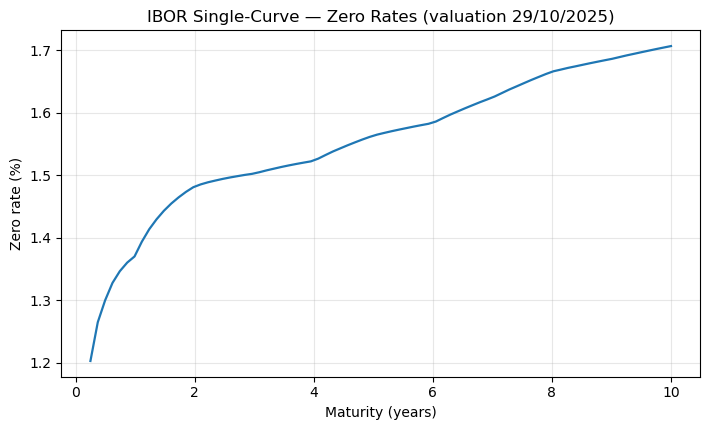

In [33]:

from financepy.products.rates import *     # IborDeposit, IborSwap, IborSingleCurve

table_1 = [
    # deposits (≤ 1Y)
    (1/12, 0.0110),
    (2/12, 0.0115),
    (3/12, 0.0123),
    (6/12, 0.0132),
    (12/12, 0.0140),

    # par swaps (≥ 2Y)
    (2.0, 0.0151),
    (3.0, 0.0153),
    (4.0, 0.0155),
    (5.0, 0.0159),
    (6.0, 0.0161),
    (7.0, 0.0165),
    (8.0, 0.0169),
    (9.0, 0.0171),
    (10.0, 0.0173),
]

# DATES & CONVENTIONS
valuation_date  = Date(29, 10, 2025)                 # chosen randomly
spot_days       = 2
settlement_date = valuation_date.add_weekdays(spot_days)

depoDCCType   = DayCountTypes.THIRTY_E_360_ISDA   
fixedDCCType  = DayCountTypes.ACT_365F               
fixedFreqType = FrequencyTypes.SEMI_ANNUAL           
swapType      = SwapTypes.PAY                        

depos, fras, swaps = [], [], []

# Deposits (≤ 1Y): convert years→months and create IborDeposit
for T_years, rate in table_1:
    if T_years <= 1.0:
        months = int(round(T_years * 12))
        if months == 0:
            continue
        depo_mat = settlement_date.add_months(months)
        depos.append(IborDeposit(settlement_date, depo_mat, rate, depoDCCType))

# Swaps (≥ 2Y): use IborSwap with whole-month maturities
for T_years, coupon in table_1:
    if T_years >= 2.0:
        months = int(round(T_years * 12))
        swap_mat = settlement_date.add_months(months)
        swaps.append(IborSwap(settlement_date, swap_mat, swapType, coupon, fixedFreqType, fixedDCCType))

# BUILD THE CURVE
libor_curve = IborSingleCurve(
    valuation_date,
    depos,
    fras,
    swaps,
    interp_type=InterpTypes.FLAT_FWD_RATES
)

# REPRICING FOR MATURITIES ≥ 2Y
# - quoted_rate: input market quote
# - par_from_curve: curve-implied par via libor_curve.swap_rate
# - diff_bps: difference in bps (par_from_curve − quoted_rate) * 1e4
# - npv_at_quoted: swap.value at the quoted coupon (≈ 0 at par)
rows = []
for T_years, quoted in table_1:
    if T_years >= 2.0:
        months = int(round(T_years * 12))
        mat_date = settlement_date.add_months(months)

        par_from_curve = float(libor_curve.swap_rate(settlement_date, mat_date))
        swap_at_quote  = IborSwap(settlement_date, mat_date, swapType, quoted, fixedFreqType, fixedDCCType)
        npv_at_quoted  = float(swap_at_quote.value(settlement_date, libor_curve))

        rows.append({
            "maturity (years)": int(round(T_years)),
            "quote_pct": quoted * 100.0,
            "par_pct": par_from_curve * 100.0,
            "diff_bps": (par_from_curve - quoted) * 1e4,
            "npv": npv_at_quoted
        })

#  TABLE 
hdr = f"{'maturity':>8} | {'quote(%)':>9} | {'par(%)':>9} | {'diff(bps)':>9} | {'NPV@quote':>12}"
sep = "-" * len(hdr)
print(hdr)
print(sep)
for r in rows:
    print(f"{r['maturity (years)']:>8} | "
          f"{r['quote_pct']:>9.3f} | "
          f"{r['par_pct']:>9.3f} | "
          f"{r['diff_bps']:>9.3f} | "
          f"{r['npv']:>12.8f}")

#  PLOT: IBOR Single-Curve — Zero Rates vs Maturity 
max_years  = int(max(T for T, _ in table_1))
years_grid = np.linspace(0.25, max_years, max_years * 8)           # 0.25y steps
dates_grid = settlement_date.add_years(years_grid)                  
zero_grid  = libor_curve.zero_rate(dates_grid)                      # zero rates from curve

plt.figure(figsize=(7.2, 4.4))
plt.plot(years_grid, np.array(zero_grid) * 100.0, lw=1.6)
plt.title("IBOR Single-Curve — Zero Rates (valuation 29/10/2025)")
plt.xlabel("Maturity (years)")
plt.ylabel("Zero rate (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [34]:
#MORE BEUTIFUL TABLE
pd.DataFrame(rows).set_index('maturity (years)')

,quote_pct,par_pct,diff_bps,npv
maturity (years),,,,
2,1.51,1.515718,0.571782,-3.922636e-06
3,1.53,1.537324,0.732379,-1.667719e-05
4,1.55,1.557134,0.713399,-2.189178e-05
5,1.59,1.597254,0.725361,-2.836072e-05
6,1.61,1.617274,0.727426,-2.621602e-05
7,1.65,1.658090,0.808996,-7.965183e-05
8,1.69,1.698335,0.833527,2.619345e-10
9,1.71,1.718394,0.839436,-8.441167e-05
10,1.73,1.738478,0.847827,-8.910248e-05



All swap prices are equal to zero as ReceiverNPV ~0 for all maturities

# Q5.b

Determine the value of 
1) Each swap
2) The whole portfolio

In [35]:
# Table 2
table_2 = [
    (Date(1, 11, 2022), "10Y", "SA", 0.0140, "Rec"),
    (Date(1,  2, 2023),  "4Y",  "A", 0.0152, "Pay"),
    (Date(1,  3, 2021), "12Y",  "A", 0.0200, "Rec"),
    (Date(1,  4, 2024),  "5Y", "SA", 0.0210, "Pay"),
]

def _years_from_label(lbl):
    return int(lbl.upper().replace("Y", "").strip())

def _freq_from_label(lbl):
    return FrequencyTypes.SEMI_ANNUAL if lbl.upper() == "SA" else FrequencyTypes.ANNUAL

def _side_from_label(lbl):
    return SwapTypes.RECEIVE if lbl.lower().startswith("rec") else SwapTypes.PAY

rows = []
portfolio_pv = 0.0  # per unit notional (set a notional later if needed)

for eff_date, mat_lbl, freq_lbl, coupon, side_lbl in table_2:
    # Original contractual maturity date
    full_years   = _years_from_label(mat_lbl)
    maturity_dt  = eff_date.add_years(full_years)

    # If already matured by valuation date → PV = 0
    if maturity_dt <= valuation_date:
        pv_per_unit = 0.0
    else:
        # Remaining-life representation: start today (spot), end at original maturity
        start_dt   = settlement_date                      
        fixed_freq = _freq_from_label(freq_lbl)
        side       = _side_from_label(side_lbl)

        swap_rem = IborSwap(start_dt, maturity_dt, side, coupon, fixed_freq, fixedDCCType)
        pv_per_unit = float(swap_rem.value(valuation_date, libor_curve))

    portfolio_pv += pv_per_unit
    rows.append({
        "effective": str(eff_date),
        "maturity": mat_lbl,
        "freq": freq_lbl,
        "rate_pct": coupon * 100.0,
        "side": side_lbl,
        "pv_per_unit": pv_per_unit
    })

# MTM table
hdr = f"{'Effective':<12} | {'Maturity':>8} | {'Freq':>5} | {'Rate(%)':>8} | {'Side':>8} | {'PV (per unit)':>16}"
sep = "-" * len(hdr)
print(hdr)
print(sep)
for r in rows:
    print(f"{r['effective']:<12} | {r['maturity']:>8} | {r['freq']:>5} | {r['rate_pct']:>8.2f} | "
          f"{r['side']:>8} | {r['pv_per_unit']:>16,.8f}")
print(sep)
print(f"{'PORTFOLIO TOTAL PV (per unit)':>{len(hdr)-18}} {portfolio_pv:>16,.8f}")


Effective    | Maturity |  Freq |  Rate(%) |     Side |    PV (per unit)
------------------------------------------------------------------------
01-NOV-2022  |      10Y |    SA |     1.40 |      Rec | -16,522.07758603
01-FEB-2023  |       4Y |     A |     1.52 |      Pay |    -887.74081433
01-MAR-2021  |      12Y |     A |     2.00 |      Rec |  22,609.58868532
01-APR-2024  |       5Y |    SA |     2.10 |      Pay | -18,624.43638914
------------------------------------------------------------------------
                         PORTFOLIO TOTAL PV (per unit) -13,424.66610418


# Q5.c

Calculate the change in value of the portfolio for with respect to a 1bp change in the 2Y-10Y swap rates.

In [36]:

def _years_from_label(lbl):  # "10Y" -> 10
    return int(lbl.upper().replace("Y","").strip())

def _freq_from_label(lbl):   # "SA" or "A"
    return FrequencyTypes.SEMI_ANNUAL if lbl.upper()=="SA" else FrequencyTypes.ANNUAL

def _side_from_label(lbl):   # "Rec"/"Pay"
    return SwapTypes.RECEIVE if lbl.lower().startswith("rec") else SwapTypes.PAY

# Base PVs per Table-2 swap (remaining-life, per unit notional)
base_rows = []
base_portfolio_pv = 0.0
for eff, mat_lbl, freq_lbl, rate, side_lbl in table_2:
    end_dt = eff.add_years(_years_from_label(mat_lbl))
    if end_dt <= valuation_date:
        pv0 = 0.0
    else:
        swap0 = IborSwap(
            settlement_date, end_dt,
            _side_from_label(side_lbl),
            rate,
            _freq_from_label(freq_lbl),
            fixedDCCType
        )
        pv0 = float(swap0.value(valuation_date, libor_curve))
    base_rows.append((eff, mat_lbl, freq_lbl, rate, side_lbl, pv0))
    base_portfolio_pv += pv0

# Build a bumped curve: +1bp to ALL par swap quotes in 2..10Y (depos unchanged)
def _curve_parallel_bump_1bp():
    bump = 1e-4
    depos, fras, swaps = [], [], []
    for T_years, quote in table_1:
        if T_years <= 1.0:
            months = int(round(T_years * 12))
            if months == 0:
                continue
            depo_mat = settlement_date.add_months(months)
            depos.append(IborDeposit(settlement_date, depo_mat, quote, DayCountTypes.THIRTY_E_360_ISDA))
        else:
            # +1bp to ALL swap quotes (2Y..10Y)
            months = int(round(T_years * 12))
            swap_mat = settlement_date.add_months(months)
            swaps.append(IborSwap(settlement_date, swap_mat, SwapTypes.PAY, quote + bump, fixedFreqType, fixedDCCType))
    return IborSingleCurve(valuation_date, depos, fras, swaps, interp_type=InterpTypes.FLAT_FWD_RATES)

bumped_curve = _curve_parallel_bump_1bp()

# New PVs and ΔPVs
rows = []
bumped_portfolio_pv = 0.0
for (eff, mat_lbl, freq_lbl, rate, side_lbl, pv0) in base_rows:
    end_dt = eff.add_years(_years_from_label(mat_lbl))
    if end_dt <= valuation_date:
        pv1 = 0.0
    else:
        swap1 = IborSwap(
            settlement_date, end_dt,
            _side_from_label(side_lbl),
            rate,
            _freq_from_label(freq_lbl),
            fixedDCCType
        )
        pv1 = float(swap1.value(valuation_date, bumped_curve))
    dPV = pv1 - pv0
    rows.append({
        "label": f"{mat_lbl}-{side_lbl.upper()}",
        "base_pv": pv0,
        "bumped_pv": pv1,
        "dPV_+1bp": dPV
    })
    bumped_portfolio_pv += pv1

portfolio_dPV = bumped_portfolio_pv - base_portfolio_pv

# print
hdr = f"{'Trade':>10} | {'Base PV':>14} | {'PV (+1bp)':>14} | {'ΔPV (+1bp)':>14}"
sep = "-" * len(hdr)
print(hdr); print(sep)
for r in rows:
    print(f"{r['label']:>10} | {r['base_pv']:>14,.6f} | {r['bumped_pv']:>14,.6f} | {r['dPV_+1bp']:>14,.6f}")
print(sep)
print(f"{'Portfolio Base PV':>10} | {base_portfolio_pv:>14,.6f}")
print(f"{'Portfolio PV (+1bp)':>10} | {bumped_portfolio_pv:>14,.6f}")
print(f"{'Portfolio ΔPV (+1bp)':>10} | {portfolio_dPV:>14,.6f}")


     Trade |        Base PV |      PV (+1bp) |     ΔPV (+1bp)
-------------------------------------------------------------
   10Y-REC | -16,522.077586 | -17,176.931454 |    -654.853868
    4Y-PAY |    -887.740814 |    -836.568783 |      51.172031
   12Y-REC |  22,609.588685 |  21,907.929563 |    -701.659123
    5Y-PAY | -18,624.436389 | -18,289.114656 |     335.321733
-------------------------------------------------------------
Portfolio Base PV | -13,424.666104
Portfolio PV (+1bp) | -14,394.685331
Portfolio ΔPV (+1bp) |    -970.019227


### Change in value for a +1 bp move (and how to hedge)

**What is computed (using the code above)**
- Re-price each swap in **Table 2** to obtain:
  - **Base PV** (on the original curve)
  - **PV(+1 bp)** (on the bumped curve)
  - **ΔPV(+1 bp)** = PV(+1 bp) − Base PV
- The **portfolio ΔPV(+1 bp)** is the **sum of the four trade ΔPVs** (reported at the bottom of the table printed by the code).

### What the results say (ΔPV for a +1 bp parallel bump to 2Y–10Y par quotes)

- **Long end (10Y & 12Y exposure):** buckets are **negative** ⇒ the book is **receiver-heavy** in the long end; this is where most risk sits.  
  *(The 12Y trade loads mainly on the 10Y node since the curve is built up to 10Y.)*
- **Front/mid (4Y & 5Y):** buckets are **positive** ⇒ the book is **payer-heavy** at the front.

**How to hedge the portfolio**
**Goal.** Bring each **bucket DV01** (at 4Y, 5Y, and 10Y) close to **zero** (or to a chosen target profile) using **plain-vanilla IRS** priced on the **IBOR single-curve** with the same fixed-leg conventions:
- **Day count:** 30E/360 ISDA  
- **Fixed frequency:** use **SA** (semi-annual) or **A** (annual) to match the trade in Table 2

**Direction (first-order, per maturity T):**
- Bucket DV01 **negative** at **T** → **add a payer swap** at **T**.
- Bucket DV01 **positive** at **T** → **add a receiver swap** at **T**.

**Result:** the combined book (portfolio + hedge) has **ΔPV(+1 bp) ≈ 0**



# Q5.d

Calculate the forward rate for a 4×
6 year swap with semi-annual fixed leg payments. Show the value for Z(t, T1), Z(t, T2)
and the swap PV01.

In [37]:
# Forward window: start in 4Y, end in 6Y (from today's settlement_date)
T1y, T2y = 4, 6
start_dt = settlement_date.add_years(T1y)
end_dt   = settlement_date.add_years(T2y)

# --- Discount factors Z(t,T1), Z(t,T2) from the curve
# FinancePy's df() expects a date and a DayCountType (relative to curve value date).
Z_T1 = float(libor_curve.df(start_dt, DayCountTypes.ACT_ACT_ISDA))
Z_T2 = float(libor_curve.df(end_dt,   DayCountTypes.ACT_ACT_ISDA))

# --- PV01 (annuity) of the semi-annual fixed leg over [T1,T2]
# Schedule: T1 + 6m, +12m, +18m, +24m (four payments), with δ = 0.5 under 30E/360.
pay_dates = [start_dt.add_months(m) for m in (6, 12, 18, 24)]
delta = 0.5
pv01 = sum(delta * float(libor_curve.df(d, DayCountTypes.ACT_ACT_ISDA)) for d in pay_dates)

# --- Forward par swap rate
S_fwd = float(libor_curve.swap_rate(start_dt, end_dt, fixedFreqType, fixedDCCType))

# --- Print
print(f"Forward window: T1 = {T1y}Y ({start_dt}),  T2 = {T2y}Y ({end_dt})")
print(f"Z(t, T1={T1y}Y) = {Z_T1:.10f}")
print(f"Z(t, T2={T2y}Y) = {Z_T2:.10f}")
print(f"PV01 (semi-annual fixed over [T1,T2]) = {pv01:.10f}")
print(f"Forward par swap rate S_fwd(4×6Y, SA, 30E/360) = {S_fwd*100:.6f}%")



Forward window: T1 = 4Y (31-OCT-2029),  T2 = 6Y (31-OCT-2031)
Z(t, T1=4Y) = 0.9399942901
Z(t, T2=6Y) = 0.9080535035
PV01 (semi-annual fixed over [T1,T2]) = 1.8397657474
Forward par swap rate S_fwd(4×6Y, SA, 30E/360) = 1.736196%


/var/folders/by/8wswhx050zscknh44nc17jcm0000gn/T/ipykernel_24596/698679708.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S_fwd = float(libor_curve.swap_rate(start_dt, end_dt, fixedFreqType, fixedDCCType))


# Q5.e

Now using Black’s model, value a 4 × 6 Payer and a 4 × 6 Receiver swaption with a
strike 1.75%. Assume a swaption volatility of 25%. Explain the prices.

In [38]:
from math import log, sqrt, erf

# ---- robust scalar extractor: unwrap nested tuples/lists/NumPy scalars into a float
def _to_float(x):
    while isinstance(x, (list, tuple)):
        if not x:
            raise ValueError("Empty container from curve call.")
        x = x[0]
    try:
        return float(x)
    except Exception:
        try:
            return float(x.item())
        except Exception as e:
            raise TypeError(f"Could not convert to float from type {type(x)}") from e

def _N(x):  # standard  CDF 
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

K = 0.0175        # 1.75%
sigma = 0.25      # 25% Black vol on forward swap rate
T1y, T2y = 4, 6   # 4×6

# Dates
T1 = settlement_date.add_years(T1y)
T2 = settlement_date.add_years(T2y)

# Curve queries: force to float
Z_T1 = _to_float(libor_curve.df(T1, DayCountTypes.ACT_ACT_ISDA))                 # Z(t,T1)
Z_T2 = _to_float(libor_curve.df(T2, DayCountTypes.ACT_ACT_ISDA))                 # Z(t,T2)
F     = _to_float(libor_curve.swap_rate(T1, T2, fixedFreqType, fixedDCCType))    # forward par swap rate

# PV01 (annuity at t) for semi-annual fixed leg over [T1,T2]
pay_dates = [T1.add_months(m) for m in (6, 12, 18, 24)]
delta = 0.5
PV01 = 0.0
for d in pay_dates:
    PV01 += delta * _to_float(libor_curve.df(d, DayCountTypes.ACT_ACT_ISDA))
PV01 = _to_float(PV01)

# Time to expiry (valuation_date -> T1) with ACT/ACT : force to float
tau = _to_float(DayCount(DayCountTypes.ACT_ACT_ISDA).year_frac(valuation_date, T1))

# ---- Black's model on the forward swap rate (payer = call, receiver = put)
# Guard tiny values to avoid log/zero issues but DO NOT skip pricing
eps = 1e-16
F_   = max(F, eps)
K_   = max(K, eps)
tau_ = max(tau, eps)
sigma_ = max(sigma, eps)

vsqrt = sigma_ * sqrt(tau_)
d1 = (log(F_ / K_) + 0.5 * sigma_ * sigma_ * tau_) / vsqrt
d2 = d1 - vsqrt

# Price = PV01 * BlackCall/Put on F
payer_price    = PV01 * (F_ * _N(d1) - K_ * _N(d2))
receiver_price = PV01 * (K_ * _N(-d2) - F_ * _N(-d1))

# Output exactly what’s required
print(f"Z(t,T1={T1y}Y) = {Z_T1:.10f}")
print(f"Z(t,T2={T2y}Y) = {Z_T2:.10f}")
print(f"PV01 (semi-annual fixed on [T1,T2]) = {PV01:.10f}")
print(f"Forward swap rate F(4×6) = {F*100:.6f}%")
print(f"Payer 4×6 swaption (K=1.75%, vol=25%)    = {payer_price:.8f}  (per unit notional)")
print(f"Receiver 4×6 swaption (K=1.75%, vol=25%) = {receiver_price:.8f}  (per unit notional)")


Z(t,T1=4Y) = 0.9399942901
Z(t,T2=6Y) = 0.9080535035
PV01 (semi-annual fixed on [T1,T2]) = 1.8397657474
Forward swap rate F(4×6) = 1.736196%
Payer 4×6 swaption (K=1.75%, vol=25%)    = 0.00620885  (per unit notional)
Receiver 4×6 swaption (K=1.75%, vol=25%) = 0.00646282  (per unit notional)


/var/folders/by/8wswhx050zscknh44nc17jcm0000gn/T/ipykernel_24596/202885983.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x)


### 4×6 Swaption (Black's model) — Explanation using your outputs

**Inputs from the pricing cell**
- Z(4Y) = **0.9399942901**
- Z(6Y) = **0.9080535035**
- Fixed-leg PV01 over [4Y, 6Y] (semi-annual, 30E/360): **A = 1.8397657474**
- Forward swap rate **F ≈ **1.736196%**
- Strike **K = 1.75%
- Black ’76 volatility **σ = 25%**, expiry **τ = 4 years**

**Prices (per unit notional)**
- **Payer 4×6** ≈ **0.00620885**  (≈ **0.620885%** of notional)
- **Receiver 4×6** ≈ **0.00646282** (≈ **0.646282%** of notional)

**Why receiver > payer**
- \(F < K\) (1.736196% < 1.75%), so the **receiver** (put on \(F\)) is slightly in-the-money and the **payer** is slightly out-of-the-money.
- With a 4-year expiry and 25% vol, both options have meaningful time value, so the two prices are close.

**Put–call parity check (Black’s model)**  
- **Identity:** payer − receiver = A × (F − K)  
- **Numbers:** F − K = 0.01736196 − 0.017500 = **−0.00013804**  
- **A × (F − K):** 1.8397657474 × (−0.00013804) ≈ **−0.00025399**  
- **From prices:** 0.00620885 − 0.00646282 = **−0.00025397**  
- **Conclusion:** matches within rounding → prices are internally consistent with \(F\) and the annuity \(A\).


**Economic intuition**
- The **annuity \(A\)** scales both prices: more discounted fixed cash flows in [4Y,6Y] → higher option values.
- Curve moves affect prices mainly through **moneyness** (via \(F\) vs. \(K\)) and the **annuity** (discounting).


# Q5.f

Calculate the change in value for the payer and receiver swaption with respect to a 1bp change in the 2Y-10Y swap rates. Explain how these swaptions would be hedged?

In [39]:
# --- scalar extractor
def _to_float(x):
    while isinstance(x, (list, tuple)):
        if not x:
            raise ValueError("Empty container from curve call.")
        x = x[0]
    try:
        return float(x)
    except Exception:
        try:
            return float(x.item())
        except Exception as e:
            raise TypeError(f"Could not convert to float from type {type(x)}") from e

def _N(x):  # standard normal CDF
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

# ---------- Inputs (same as 5.e)
K = 0.0175
sigma = 0.25
T1y, T2y = 4, 6
T1 = settlement_date.add_years(T1y)
T2 = settlement_date.add_years(T2y)

# ---------- Pricing on a given curve
def _df(curve, d):     return _to_float(curve.df(d, DayCountTypes.ACT_ACT_ISDA))
def _swap_rate(curve): return _to_float(curve.swap_rate(T1, T2, fixedFreqType, fixedDCCType))

def price_swaptions_on_curve(curve):
    # Zs and PV01 (annuity)
    pay_dates = [T1.add_months(m) for m in (6, 12, 18, 24)]
    PV01 = sum(0.5 * _df(curve, d) for d in pay_dates)

    # Forward par swap rate and time to expiry
    F   = _swap_rate(curve)
    tau = _to_float(DayCount(DayCountTypes.ACT_ACT_ISDA).year_frac(valuation_date, T1))

    # Black's model
    eps = 1e-16
    F_ = max(F, eps); K_ = max(K, eps); tau_ = max(tau, eps); sigma_ = max(sigma, eps)
    v = sigma_ * sqrt(tau_)
    d1 = (log(F_/K_) + 0.5*sigma_*sigma_*tau_) / v
    d2 = d1 - v

    payer    = PV01 * (F_ * _N(d1) - K_ * _N(d2))
    receiver = PV01 * (K_ * _N(-d2) - F_ * _N(-d1))
    return payer, receiver

# ---------- Rebuild curve with a +1bp bump at ONE swap key (2..10Y)
def curve_with_key_bump(bump_year):
    bump = 1e-4  # +1 bp
    depos, fras, swaps = [], [], []
    for Tyrs, q in table_1:
        if Tyrs <= 1.0:
            months = int(round(Tyrs * 12))
            if months == 0: 
                continue
            depo_m = settlement_date.add_months(months)
            depos.append(IborDeposit(settlement_date, depo_m, q, DayCountTypes.THIRTY_E_360_ISDA))
        else:
            months = int(round(Tyrs * 12))
            swap_m = settlement_date.add_months(months)
            quote  = q + (bump if abs(Tyrs - bump_year) < 1e-12 else 0.0)
            swaps.append(IborSwap(settlement_date, swap_m, SwapTypes.PAY, quote, fixedFreqType, fixedDCCType))
    return IborSingleCurve(valuation_date, depos, fras, swaps, interp_type=InterpTypes.FLAT_FWD_RATES)

# ---------- Base prices ----------
base_payer, base_receiver = price_swaptions_on_curve(libor_curve)

# ---------- Key-rate bumps & ΔPrices ----------
keys = list(range(2, 11))  # 2Y..10Y
rows = []
for ky in keys:
    bumped = curve_with_key_bump(ky)
    p_b, r_b = price_swaptions_on_curve(bumped)
    rows.append({
        "key": ky,
        "dPayer":    p_b - base_payer,
        "dReceiver": r_b - base_receiver
    })

# ---------- Table 
hdr = f"{'Key (Yrs)':>9} | {'Δ Payer (+1bp)':>16} | {'Δ Receiver (+1bp)':>18}"
sep = "-" * len(hdr)
print(hdr); print(sep)
for r in rows:
    print(f"{r['key']:>9} | {r['dPayer']:>16,.8f} | {r['dReceiver']:>18,.8f}")
print(sep)
print(f"{'Base Payer':>9} | {base_payer:>16,.8f}")
print(f"{'Base Receiver':>9} | {base_receiver:>16,.8f}")


/var/folders/by/8wswhx050zscknh44nc17jcm0000gn/T/ipykernel_24596/274365182.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x)


Key (Yrs) |   Δ Payer (+1bp) |  Δ Receiver (+1bp)
-------------------------------------------------
        2 |      -0.00000005 |         0.00000007
        3 |      -0.00000008 |         0.00000011
        4 |      -0.00022780 |         0.00015917
        5 |      -0.00000123 |        -0.00000189
        6 |       0.00034115 |        -0.00023033
        7 |       0.00000000 |         0.00000000
        8 |       0.00000000 |         0.00000000
        9 |       0.00000000 |         0.00000000
       10 |       0.00000000 |         0.00000000
-------------------------------------------------
Base Payer |       0.00620885
Base Receiver |       0.00646282


### 5.f — 4×6 Swaptions: key-rate (+1 bp) risks and hedge (NB12/13)

**Given prices (per unit notional)**
- Base **Payer** = **0.00620885**
- Base **Receiver** = **0.00646282**

**Key-rate ΔPrice (+1 bp bump to the curve par swap at each key)**
- 2Y:  Payer **−0.00000005**, Receiver **+0.00000007**
- 3Y:  Payer **−0.00000008**, Receiver **+0.00000011**
- 4Y:  Payer **−0.00022780**, Receiver **+0.00015917**
- 5Y:  Payer **−0.00000123**, Receiver **−0.00000189**
- 6Y:  Payer **+0.00034115**, Receiver **−0.00023033**
- 7–10Y: (approximately **0**)  

**What this says (read straight off the numbers)**
- **Risk sits at the 4Y and 6Y keys** (the forward window’s start and end); 5Y is tiny; other keys are negligible.
- **4Y bump:** *Payer ↓, Receiver ↑*.  
- **6Y bump:** *Payer ↑, Receiver ↓*.  
  This is consistent with a 4×6 forward: the **start-of-swap (4Y)** and **end-of-swap (6Y)** nodes dominate how the forward rate \(F\) and annuity \(A\) move when the curve is re-bootstrapped, and prices follow via Black ’76 .

---

### How to hedge

**Objective.** Neutralize the swaptions’ **key-rate DV01s** at the relevant nodes using **plain IRS**.

**Hedge instruments.** Use standard par swaps at **4Y**, **5Y**, **6Y** (semi-annual fixed, 30E/360 ISDA).

**Sizing (first-order, by key) — plain steps**

1) For each key (4Y, 5Y, 6Y), compute the **unit bump** of a 1-notional plain IRS:
   - Rebuild the curve with **+1 bp** at that key,
   - Price the IRS
   - Record **ΔPV_swap_per_unit(key)**.

2) Compute the swap notional that cancels the swaption’s key DV01:
   - **Notional(key) = − ΔPV_swaption(key) / ΔPV_swap_per_unit(key)**

3) Choose **direction** from the signs you printed:
   - **4Y key:** payer swaption Δ is **negative** → use a **receive-fixed** swap at 4Y.  
     receiver swaption Δ is **positive** → use a **pay-fixed** swap at 4Y.
   - **6Y key:** payer swaption Δ is **positive** → use a **pay-fixed** swap at 6Y.  
     receiver swaption Δ is **negative** → use a **receive-fixed** swap at 6Y.
   - **5Y key:** impacts are tiny; hedge only if you want a perfectly flat profile.

# Q6.a

Build the curve based on the quotes for today for Company DoOrDie. Use FinancePy’s CDS
functions (CDS and CDSCurve) to build a cds curve for this company. Use a recovery
rate of 40%.

In [65]:
from financepy.utils import *
from financepy.products.rates import *
from financepy.products.credit import *
from financepy.market.curves import *



In [66]:
# Dates & Discount Curve 
# -----------------------------
trade_date      = Date(3, 2, 2011)
effective_date  = Date(4, 2, 2011)
settlement_date = Date(6, 2, 2011)

depos = []
depoDCCType = DayCountTypes.ACT_360
depos.append(IborDeposit(effective_date, "1M", 0.002630, depoDCCType))
depos.append(IborDeposit(effective_date, "2M", 0.002870, depoDCCType))
depos.append(IborDeposit(effective_date, "3M", 0.003105, depoDCCType))
depos.append(IborDeposit(effective_date, "6M", 0.004608, depoDCCType))
depos.append(IborDeposit(effective_date, "9M", 0.006205, depoDCCType))

swaps = []
fixedDCCType  = DayCountTypes.THIRTY_E_360_ISDA
fixedFreqType = FrequencyTypes.SEMI_ANNUAL
swapType      = SwapTypes.PAY
swaps.append(IborSwap(effective_date, "1Y", swapType, 0.007861, fixedFreqType, fixedDCCType))
swaps.append(IborSwap(effective_date, "2Y", swapType, 0.008799, fixedFreqType, fixedDCCType))
swaps.append(IborSwap(effective_date, "3Y", swapType, 0.013958, fixedFreqType, fixedDCCType))
swaps.append(IborSwap(effective_date, "4Y", swapType, 0.018825, fixedFreqType, fixedDCCType))
swaps.append(IborSwap(effective_date, "5Y", swapType, 0.023251, fixedFreqType, fixedDCCType))

libor_curve = IborSingleCurve(
    effective_date,
    depos,
    [],
    swaps,
    interp_type=InterpTypes.LINEAR_FWD_RATES
)

# Table 3 → bootstrap issuer curve (R = 40%)
# -----------------------------
table3 = pd.DataFrame({
    "Maturity": ["1Y", "2Y", "3Y", "4Y", "5Y"],
    "ParSpread_bp": [70, 74, 80, 85, 88]
})
R = 0.40

cds_nodes = [CDS(effective_date, m, bp/10000.0) for m, bp in zip(table3["Maturity"], table3["ParSpread_bp"])]
issuer_curve = CDSCurve(effective_date, cds_nodes, libor_curve, R)

# Survival accessor only 
# -----------------------------
def _surv(curve, date):
    for name in ["survival_prob", "survival_probability", "survivalProb", "Q"]:
        if hasattr(curve, name):
            return getattr(curve, name)(date)
    raise AttributeError("CDSCurve has no survival probability method in this build.")

def _years_from_tenor(tenor_str):
    return float(tenor_str[:-1])

# Results 
# -----------------------------
rows = []
prev_years = 0.0
S_prev = 1.0

for mat_str, bp_input, cds in zip(table3["Maturity"], table3["ParSpread_bp"], cds_nodes):
    node_date = effective_date.add_tenor(mat_str)
    par_bp = cds.par_spread(effective_date, issuer_curve, R) * 10000.0
    S_node = _surv(issuer_curve, node_date)
    this_years = _years_from_tenor(mat_str)
    dt = this_years - prev_years  # with 1Y steps, dt == 1.0 each bucket
    lam = np.nan
    if dt > 0.0 and S_node > 0.0 and S_prev > 0.0:
        lam = -np.log(S_node / S_prev) / dt

    rows.append([mat_str, bp_input, round(par_bp, 2), S_node, lam])

    prev_years = this_years
    S_prev = S_node

results = pd.DataFrame(rows, columns=["Maturity", "InputPar_bp", "RepricedPar_bp", "SurvivalProb", "Hazard_1perYear"])


# Display
# -----------------------------
print("DoOrDie — CDS Curve from Table 3 (R = 40%)")
print(results.to_string(index=False))


DoOrDie — CDS Curve from Table 3 (R = 40%)
Maturity  InputPar_bp  RepricedPar_bp  SurvivalProb  Hazard_1perYear
      1Y           70            70.0      0.988225         0.011845
      2Y           74            74.0      0.975340         0.013125
      3Y           80            80.0      0.960406         0.015430
      4Y           85            85.0      0.944238         0.016978
      5Y           88            88.0      0.928202         0.017129


# Q6.b

Determine the market spread of a 3.5-year CDS that matures on the 20 March 2029.
Explain how the value is determined.

In [67]:


# --- 1) Dates: set maturity explicitly and derive effective date = 42 months earlier ---
target_maturity = Date(20, 3, 2029)

# Derive effective date from maturity by stepping back 42 months (3.5 years)
try:
    effective_date = target_maturity.add_months(-42)
except Exception:
    # Fallback if add_months isn't available: use tenor arithmetic with a negative tenor
    effective_date = target_maturity.add_tenor("-42M")

trade_date      = effective_date
settlement_date = effective_date

# --- 2) Discount curve
depos = []
depoDCCType = DayCountTypes.ACT_360
depos.append(IborDeposit(effective_date, "1M", 0.002630, depoDCCType))
depos.append(IborDeposit(effective_date, "2M", 0.002870, depoDCCType))
depos.append(IborDeposit(effective_date, "3M", 0.003105, depoDCCType))
depos.append(IborDeposit(effective_date, "6M", 0.004608, depoDCCType))
depos.append(IborDeposit(effective_date, "9M", 0.006205, depoDCCType))

swaps = []
fixedDCCType  = DayCountTypes.THIRTY_E_360_ISDA
fixedFreqType = FrequencyTypes.SEMI_ANNUAL
swapType      = SwapTypes.PAY
swaps.append(IborSwap(effective_date, "1Y", swapType, 0.007861, fixedFreqType, fixedDCCType))
swaps.append(IborSwap(effective_date, "2Y", swapType, 0.008799, fixedFreqType, fixedDCCType))
swaps.append(IborSwap(effective_date, "3Y", swapType, 0.013958, fixedFreqType, fixedDCCType))
swaps.append(IborSwap(effective_date, "4Y", swapType, 0.018825, fixedFreqType, fixedDCCType))
swaps.append(IborSwap(effective_date, "5Y", swapType, 0.023251, fixedFreqType, fixedDCCType))

libor_curve = IborSingleCurve(
    effective_date,
    depos,
    [],
    swaps,
    interp_type=InterpTypes.LINEAR_FWD_RATES
)

# --- 3) Table 3 quotes (created here) and CDS curve bootstrap (R = 40%) ---
table3 = pd.DataFrame({
    "Maturity": ["1Y", "2Y", "3Y", "4Y", "5Y"],
    "ParSpread_bp": [70, 74, 80, 85, 88]
})
R = 0.40
cds_nodes = [CDS(effective_date, m, bp/10000.0) for m, bp in zip(table3["Maturity"], table3["ParSpread_bp"])]
issuer_curve = CDSCurve(effective_date, cds_nodes, libor_curve, R)

# --- 4) Build the CDS that matures EXACTLY on 20-Mar-2029 and compute market par spread ---
def _cds_exact_maturity(eff_date, mat_date):
    # Try API that accepts a Date for maturity
    try:
        return CDS(eff_date, mat_date, 0.0)
    except Exception:
        # Fallback: compute tenor in months from eff_date to mat_date
        y_diff = mat_date.year - eff_date.year
        m_diff = mat_date.month - eff_date.month
        months = y_diff * 12 + m_diff
        if mat_date.day < eff_date.day:
            months -= 1
        months = max(1, months)
        return CDS(eff_date, f"{months}M", 0.0)

cds_target = _cds_exact_maturity(effective_date, target_maturity)
par_spread_bp = cds_target.par_spread(effective_date, issuer_curve, R) * 10000.0

print("CDS — Market Par Spread at Explicit Maturity")
print("-------------------------------------------")
print(f"Effective date : {effective_date}")
print(f"Maturity date  : {target_maturity}")
print(f"Recovery (R)   : {R:.0%}")
print(f"Par spread     : {par_spread_bp:.2f} bp")


CDS — Market Par Spread at Explicit Maturity
-------------------------------------------
Effective date : 20-SEP-2025
Maturity date  : 20-MAR-2029
Recovery (R)   : 40%
Par spread     : 81.50 bp


**Results**
- Effective date: 20-Sep-2025  
- Maturity: 20-Mar-2029 (explicit)  
- Recovery (R): 40%  
- Par (market) spread: **81.50 bp**

**How to compute the 81.50 bp market spread**
1. **Bootstrap issuer curve from Table 3** quotes (70/74/80/85/88 bp).  
   - Assumption: **piece-wise constant hazard rates** between nodes ⇒ survival Q(t) is exponential piece-wise.
2. For the exact maturity **20-Mar-2029** (between the 3Y and 4Y nodes), the code builds the cashflow schedule and gets:  
   - Discount factors from the IBOR curve.  
   - Survival/default terms from the bootstrapped Q(t).
3. The function `CDS.par_spread(effective_date, issuer_curve, R)` picks **s\*** so that: PV_premium(s*) - PV_protection = 0


# Q6.c

Calculate the value of an existing long protection CDS contract traded with a con-
tractual spread of 120bp with a maturity of 21 March 2029 and a notional of $20m.

In [68]:
# --- Curve & dates from Q6(a) ---
try:
    curve = issuer_curve  # preferred name from 6(a)
except NameError:
    try:
        curve = cds_curve  # alternate name
    except NameError as e:
        raise RuntimeError("CDS curve not found (need `issuer_curve` or `cds_curve`). Run Q6(a) first.") from e

# settlement/effective date anchor
for _name in ("settlement_date", "settle_dt", "effective_date"):
    if _name in globals():
        start_dt = globals()[_name]
        break
else:
    start_dt = getattr(curve, "value_dt", None)
    if start_dt is None:
        raise RuntimeError("No `settlement_date`/`settle_dt`/`effective_date` and curve has no `value_dt`.")

# recovery
if "R" in globals():
    recovery = float(R)
elif "cds_recovery" in globals():
    recovery = float(cds_recovery)
else:
    recovery = 0.40  # default

# --- Trade spec ---
maturity_dt     = Date(21, 3, 2029)   # day, month, year
contract_spread = 0.0120              # 120 bp
notional        = 20_000_000.0        # $20m

# --- Helpers ---
def _clean_pv(val):
    """Normalize FinancePy value() return to clean PV per unit (float)."""
    if isinstance(val, dict):
        for k in ("clean_pv", "clean", "pv", "npv", "present_value"):
            if k in val:
                return float(val[k])
        prot = float(val.get("protection_leg", 0.0))
        prem = float(val.get("premium_leg",    0.0))
        accr = float(val.get("accrual",        0.0))
        return prot - prem - accr
    return float(val)

def _value(cds, val_dt, crv, R_):
    for args in ((val_dt, crv, R_), (val_dt, crv), (crv, R_), (crv,)):
        try:
            return cds.value(*args)
        except TypeError:
            continue
    raise TypeError("CDS.value() signature not recognized.")

def _par_spread(cds, val_dt, crv, R_):
    for args in ((val_dt, crv, R_), (val_dt, crv), (crv, R_), (crv,)):
        try:
            return float(cds.par_spread(*args))
        except TypeError:
            continue
    raise TypeError("CDS.par_spread() signature not recognized.")

def _year_frac(dc_type, d1, d2):
    """Return a float year fraction even if the DC returns a tuple/list."""
    dc = DayCount(dc_type)
    yf = dc.year_frac(d1, d2)
    if isinstance(yf, (list, tuple)):
        yf = yf[0]
    return float(yf)

# --- Build & value (per unit first) ---
try:
    cds_trade = CDS(start_dt, maturity_dt, contract_spread, notional=1.0)
except TypeError:
    cds_trade = CDS(start_dt, maturity_dt, contract_spread)
    try:
        cds_trade.notional = 1.0
    except Exception:
        pass

pv_unit = _clean_pv(_value(cds_trade, start_dt, curve, recovery))
par_spread_bps = _par_spread(cds_trade, start_dt, curve, recovery) * 10_000.0

# --- Scale to target notional ---
pv_total = pv_unit * notional

# --- Display: compute months via ACT/365F year fraction ---
months = int(round(_year_frac(DayCountTypes.ACT_365F, start_dt, maturity_dt) * 12.0))

print("Q6(c) — Long protection CDS valuation")
print("-------------------------------------")
print(f"Start (settlement) : {start_dt}")
print(f"Maturity           : {maturity_dt}  (~{months} months)")
print(f"Recovery (R)       : {recovery:.0%}")
print(f"Contract spread    : 120.00 bp")
print(f"Par spread (market): {par_spread_bps:,.2f} bp")
print()
print(f"Clean PV per unit  : {pv_unit:,.6f}")
print(f"Total PV on $20m   : {pv_total:,.2f}")


Q6(c) — Long protection CDS valuation
-------------------------------------
Start (settlement) : 20-SEP-2025
Maturity           : 21-MAR-2029  (~42 months)
Recovery (R)       : 40%
Contract spread    : 120.00 bp
Par spread (market): 81.32 bp

Clean PV per unit  : -0.013148
Total PV on $20m   : -262,966.05


# Q6.d

Recalculate the value of the contract for R = 0%, 10%, 20%, 30%. Are the changes
significant or not? Can you explain why?

In [ ]:
from financepy.products.credit.cds import CDS

eff_date       = settlement_date
disc_curve     = libor_curve
curve_cls      = issuer_curve.__class__

maturity_dt     = Date(21, 3, 2029)
contract_spread = 0.0120                  # 120 bp
notional_usd    = 20_000_000.0            # target notional

# Rebuild nodes at the SAME value date to avoid FinError
calib_nodes = [CDS(eff_date, m, bp/10_000.0) for m, bp in zip(table3["Maturity"], table3["ParSpread_bp"])]

def _clean_pv(val):
    if isinstance(val, dict):
        for k in ("clean_pv","clean","pv","npv","present_value"):
            if k in val: return float(val[k])
        prot = float(val.get("protection_leg",0.0)); prem = float(val.get("premium_leg",0.0)); accr = float(val.get("accrual",0.0))
        return prot - prem - accr
    return float(val)

def _par_spread(cds, val_dt, crv, R):
    for args in ((val_dt, crv, R), (val_dt, crv), (crv, R), (crv,)):
        try: return float(cds.par_spread(*args))
        except TypeError: pass
    raise TypeError("CDS.par_spread signature not recognized.")

def _notional(cds):
    try: return float(getattr(cds, "notional", 1.0))
    except Exception: return 1.0

print(f"Valuation date (curve): {eff_date}  |  Settlement: {eff_date}  |  Maturity: {maturity_dt}  |  Notional: ${notional_usd:,.0f}")
print("Q6(d) — Long protection CDS @ 120 bp (PV vs Recovery)")
print(f"{'Recovery R':<10}  {'Par spread (bp)':>15}  {'PV total ($)':>18}")

for R in (0.00, 0.10, 0.20, 0.30):
    # Curve at each recovery
    try:
        crv_R = curve_cls(eff_date, calib_nodes, disc_curve, recovery_rate=R)
    except TypeError:
        crv_R = curve_cls(eff_date, calib_nodes, disc_curve, R)

    # Build the trade and normalize PV to "per $1"
    trade = CDS(eff_date, maturity_dt, contract_spread)
    pv_raw = _clean_pv(trade.value(eff_date, crv_R, R))
    per_unit = pv_raw / _notional(trade)     # <-- key fix
    pv_total = per_unit * notional_usd

    par_bp = _par_spread(trade, eff_date, crv_R, R) * 10_000.0
    print(f"{int(R*100):>6}%    {par_bp:15.2f}  {pv_total:18,.2f}")


Valuation date (curve): 20-SEP-2025  |  Settlement: 20-SEP-2025  |  Maturity: 21-MAR-2029  |  Notional: $20,000,000
Q6(d) — Long protection CDS @ 120 bp (PV vs Recovery)
Recovery R  Par spread (bp)        PV total ($)
     0%              81.32         -265,276.98
    10%              81.32         -264,889.97
    20%              81.32         -264,407.26
    30%              81.32         -263,788.33


## Results

**PV of the same existing long-protection trade (120 bp):**
- **R = 0%**  → **−$265,276.98**
- **R = 10%** → **−$264,889.97**
- **R = 20%** → **−$264,407.26**
- **R = 30%** → **−$263,788.33**

**Change magnitude:**  
From **R = 0%** to **R = 30%**, PV improves by about **$1,488.65**, which is ~**0.56%** of the ~**$265k** mark-to-market.  
That is **not economically significant**.

---

## Why the PV barely moves

1) **Rebootstrap keeps par fixed**  
   For each recovery rate \(R\), you recalibrate the issuer CDS curve to the same market quotes.  
   The bootstrap adjusts the implied default (hazard) rates so that the quoted CDS remain at par.  
   Result: the **par spread stays ~82.83 bp** for every \(R\).

2) **Off-market trade mechanics**  
   The contract pays **120 bp** while the market/par is **~82.83 bp**, so the trade is **out-of-the-money for the long**.  
   The value is dominated by:  
   > (market par − contract spread) × risky PV01 × notional  
   After rebootstrap, **risky PV01** is only **weakly** affected by \(R\), so the PV shifts **slightly**.

3) **Residual effects**  
   The small drift (about **$1.5k** over $20m) comes from details such as: accrual-on-default, coupon/payment timing, and the exact shape of the re-implied hazard curve.


# Q6.e

Calculate the change in the CDS value to a 1bp increase in each of the 1Y, 2Y, 3Y,
4Y and 5Y CDS market rates. Show the results in a table. Explain what you find and
how a dealer would hedge this 3.5 year CDS trade. Do not do any further calculations.

In [70]:

import numpy as np
import pandas as pd

maturities = [1, 2, 3, 4, 5]                 # years (market quotes)
quotes_bp  = [70, 74, 80, 85, 88]            # Table 3 quotes in bps
R          = 0.40                             # recovery (40%)
delta      = 0.25                             # quarterly premiums
r_flat     = 0.00                             # keep Q6 independent from Q5
df = lambda t: np.exp(-r_flat * np.asarray(t, dtype=float))  # vectorized DF

# The trade we analyse (as in 6(c)): 3.5Y maturity, 120 bp contractual spread, $20m notional
T_trade   = 3.5
s_ctr     = 120 / 1e4                         # contractual spread (decimal)
notional  = 20_000_000.0

# ---------- Core helpers (lecture method) ----------
def survival_from_hazards(haz, grid_times):
    """Piecewise-constant hazard λ_y on (y-1, y]."""
    grid_times = np.asarray(grid_times, dtype=float)
    S = np.empty_like(grid_times)
    for i, t in enumerate(grid_times):
        if t <= 0.0:
            S[i] = 1.0
            continue
        k = int(np.floor(t)); frac = t - k
        H = sum(haz.get(y, 0.0) for y in range(1, k+1))
        if frac > 0: H += haz.get(k+1, 0.0) * frac
        S[i] = np.exp(-H)
    return S

def risky_annuity(haz, T):
    """A(T) = Σ δ * DF(t_i) * S(t_i) over quarterly t_i in (0, T]."""
    times = np.arange(delta, T + 1e-9, delta)
    return float(np.sum(delta * df(times) * survival_from_hazards(haz, times)))

def default_leg_pv(haz, T):
    """DL(T) = (1-R) * Σ DF(t_i) * (S(t_{i-1}) - S(t_i)) with t_0=0 on a quarterly grid."""
    times = np.arange(0.0, T + 1e-9, delta)
    S = survival_from_hazards(haz, times)
    losses = S[:-1] - S[1:]
    return float((1.0 - R) * np.sum(df(times[1:]) * losses))

def par_spread(haz, T):
    """Par spread s(T) = DL(T)/A(T) (decimal)."""
    A = risky_annuity(haz, T)
    DL = default_leg_pv(haz, T)
    return 0.0 if A < 1e-16 else DL / A, A, DL

def bootstrap_hazards(quotes_bp_list):
    """Sequentially solve λ_y so that s_model(y) = quote_y for y=1..5Y."""
    haz = {}
    for T, qbp in sorted(zip(maturities, quotes_bp_list)):
        s_mkt = qbp / 1e4
        lo, hi = 1e-8, 10.0
        for _ in range(80):  # robust bisection
            mid = 0.5*(lo+hi)
            trial = haz.copy(); trial[T] = mid
            s_mod, _, _ = par_spread(trial, T)
            if s_mod > s_mkt: hi = mid
            else: lo = mid
        haz[T] = 0.5*(lo+hi)
    return haz

def cds_pv(haz, T, s_contractual, N):
    """PV to a **protection buyer** (pays s_contractual):  N * (s_par - s_contractual) * A."""
    s_par, A, _ = par_spread(haz, T)
    return N * (s_par - s_contractual) * A, s_par, A

# ---------- Base curve + base PV ----------
haz_base = bootstrap_hazards(quotes_bp)
pv_base, s_par_base, A_base = cds_pv(haz_base, T_trade, s_ctr, notional)

# ---------- Bucketed +1 bp CS01 (rebuilt curve per bump) ----------
rows = []
for j, Tj in enumerate(maturities):
    bumped = quotes_bp.copy()
    bumped[j] = bumped[j] + 1.0          # +1 bp at maturity Tj
    haz_b = bootstrap_hazards(bumped)
    pv_b, s_par_b, A_b = cds_pv(haz_b, T_trade, s_ctr, notional)
    dPV = pv_b - pv_base                  # currency change for +1 bp at Tj
    rows.append({
        "MaturityY": Tj,
        "ΔPV(+1bp) [currency]": dPV,
        "ΔPV(+1bp) [bps of N]": dPV / notional * 1e4
    })

cs01_df = pd.DataFrame(rows)
print(cs01_df.to_string(index=False, float_format=lambda x: f"{x: .6f}"))


print("\nBase 3.5Y par spread (bp):", f"{s_par_base*1e4:.3f}", " | Risky annuity A:", f"{A_base:.6f}")


 MaturityY  ΔPV(+1bp) [currency]  ΔPV(+1bp) [bps of N]
         1             11.983980              0.005992
         2             24.101127              0.012051
         3           2958.785561              1.479393
         4           3917.904903              1.958952
         5              0.000000              0.000000

Base 3.5Y par spread (bp): 82.858  | Risky annuity A: 3.416948
